# Aula 12 — Análise de Comportamento do ILS para o CVRP da Prolog

**ENG 4560 — Projeto Integrado VI: Distribuição Física | Grupo 2**

Na Aula 11 o Iterated Local Search (ILS) foi implementado e produziu a primeira solução melhorada para as instâncias C1–C4. A pergunta deixa de ser *o algoritmo funciona?* e passa a ser *como ele se comporta?*. Este notebook responde a essa pergunta em três frentes, todas com implicação direta na recomendação operacional para a Prolog e na configuração a levar para a instância de competição da Sprint 3.

A configuração da Equipe 2, fixada no Sprint Planning #3, orienta toda a análise: perturbação **double-bridge**, critério de aceitação **estrito**, busca local **2-opt + Relocate** e semente 42. O estudo se organiza assim: (1) sensibilidade aos parâmetros `k` (intensidade da perturbação) e `N` (número de iterações); (2) diagnóstico de convergência, distinguindo convergência genuína de estagnação prematura; (3) escalabilidade ao longo das quatro instâncias C1–C4. A instância de trabalho das Seções 1 e 2 é a **C4** (60 clientes, trilha Nearest Neighbor), a maior e mais estruturada da base, onde o ILS da Aula 11 ainda melhorava perto do fim do orçamento de iterações.

Os dados e a biblioteca de funções reproduzem o código de referência da Aula 12 do professor; a única diferença é o carregamento direto dos arquivos locais (instâncias da Aula 2 e soluções pós-busca-local da Aula 8), sem o `upload` do Colab.

## Seção 0 — Ambiente, dados e biblioteca de funções

Esta seção prepara tudo o que as análises consomem: importações, caminhos relativos para os dados, carregamento das quatro instâncias C1–C4 (Aula 2) e das soluções pós-busca-local (Aula 8), e a biblioteca de avaliação, busca local, perturbação e ILS. As funções são as mesmas da Aula 11, acrescidas do parâmetro `k` nas perturbações — sem essa intensidade variável a análise de sensibilidade da Seção 1 não existiria.

### 0.1 Importações e caminhos

In [1]:
import copy
import json
import random
import time

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from IPython.display import display

DATASETS_DIR = Path("../../2/datasets")
SOLUTIONS_BL_DIR = Path("../../8/Aula8_Busca_Local/files")
OUTPUT_FILES_DIR = Path("files")
OUTPUT_FILES_DIR.mkdir(exist_ok=True)
IMAGES_DIR = Path("images")
IMAGES_DIR.mkdir(exist_ok=True)

INSTANCIAS = {
    "C1": "Equipe_2_C1_10",
    "C2": "Equipe_2_C2_25",
    "C3": "Equipe_2_C3_40",
    "C4": "Equipe_2_C4_60",
}
HEURISTICAS = ["NN", "CW"]

# Paleta padronizada das curvas e barras (mesma do código de referência da Aula 12).
CORES = {
    "k1": "#2196F3", "k2": "#4CAF50", "k3": "#FF9800", "k4": "#E91E63",
    "melhor": "#E53935", "atual": "#90CAF9", "baseline": "#9E9E9E", "ils": "#2E7D32",
}

assert DATASETS_DIR.exists(), f"Diretório de instâncias não encontrado: {DATASETS_DIR.resolve()}"
assert SOLUTIONS_BL_DIR.exists(), f"Diretório de soluções pós-BL não encontrado: {SOLUTIONS_BL_DIR.resolve()}"

print("Datasets (Aula 2):       ", DATASETS_DIR.resolve())
print("Soluções pós-BL (Aula 8):", SOLUTIONS_BL_DIR.resolve())
print("Instâncias:", list(INSTANCIAS.keys()))

Datasets (Aula 2):        C:\Users\rodri\OneDrive\Documentos\Claude\Cowork\Proj. Distribuição Fisica\Aulas\2\datasets
Soluções pós-BL (Aula 8): C:\Users\rodri\OneDrive\Documentos\Claude\Cowork\Proj. Distribuição Fisica\Aulas\8\Aula8_Busca_Local\files
Instâncias: ['C1', 'C2', 'C3', 'C4']


### 0.2 Carregamento das instâncias C1–C4

Cada instância traz a matriz de distâncias `D`, os vetores de demanda `q` e tempo de atendimento `s`, e o `params.json` com a configuração de frota e custos. A função `normalize_params` (idêntica à do código de referência) aceita tanto o formato das aulas quanto o da instância secreta, convertendo nomes de veículos e chaves para um dicionário operacional único.

In [2]:
def normalize_params(params_raw):
    # Caso 1: padrão já usado nas aulas de heurísticas.
    if all(k in params_raw for k in ["capacity", "fixed_cost", "cost_per_km", "speed_kmh", "max_hours"]):
        return {
            "capacity": params_raw["capacity"],
            "fixed_cost": params_raw["fixed_cost"],
            "cost_per_km": params_raw["cost_per_km"],
            "speed_kmh": params_raw["speed_kmh"],
            "max_hours": params_raw["max_hours"],
        }

    # Caso 2: padrão da instância secreta (VEHICLES, g_R$/km, v_kmh, H_horas).
    if "VEHICLES" in params_raw:
        vehicles = params_raw["VEHICLES"]
        capacity, fixed_cost = {}, {}
        for key, val in vehicles.items():
            key_up = key.upper()
            name = "FIO" if key_up in ("FIO", "FIORINO") else ("VUC" if key_up == "VUC" else key_up)
            capacity[name] = val.get("Q_kg", val.get("capacity"))
            fixed_cost[name] = val.get("fixed_cost", val.get("custo_fixo_diario"))
        return {
            "capacity": capacity,
            "fixed_cost": fixed_cost,
            "cost_per_km": params_raw.get("cost_per_km", params_raw.get("g_R$/km", 1.50)),
            "speed_kmh": params_raw.get("speed_kmh", params_raw.get("v_kmh", 40.0)),
            "max_hours": params_raw.get("max_hours", params_raw.get("H_horas", 8.0)),
        }

    raise ValueError("Formato de params.json não reconhecido.")


def load_instance(name):
    folder = DATASETS_DIR / INSTANCIAS[name]
    nodes = pd.read_csv(folder / "nodes.csv")
    D = np.load(folder / "D.npy")
    q = np.load(folder / "q.npy")
    s = np.load(folder / "s.npy")
    params_raw = json.loads((folder / "params.json").read_text(encoding="utf-8"))

    n = len(nodes)
    assert D.shape == (n, n), f"Dimensão incorreta de D em {name}"
    assert q.shape == (n,), f"Dimensão incorreta de q em {name}"
    assert s.shape == (n,), f"Dimensão incorreta de s em {name}"

    return {
        "name": name,
        "n_clientes": n - 1,
        "nodes": nodes,
        "D": D,
        "q": q,
        "s": s,
        "params": normalize_params(params_raw),
    }


INST = {name: load_instance(name) for name in INSTANCIAS}

linhas = []
for name, inst in INST.items():
    linhas.append({
        "instancia": name,
        "n_clientes": inst["n_clientes"],
        "demanda_total_kg": round(float(inst["q"][1:].sum()), 2),
        "maior_demanda_kg": round(float(inst["q"][1:].max()), 2),
        "s_por_cliente_h": round(float(inst["s"][1:].mean()), 3),
    })
display(pd.DataFrame(linhas).set_index("instancia"))

,n_clientes,demanda_total_kg,maior_demanda_kg,s_por_cliente_h
instancia,,,,
C1,10,141.56,52.95,0.25
C2,25,754.48,129.25,0.25
C3,40,1295.25,153.56,0.25
C4,60,1958.12,206.05,0.25


As quatro instâncias reproduzem o perfil das Aulas 7, 8 e 11: 10, 25, 40 e 60 clientes, com demanda total subindo de 141,56 kg em C1 para 1.958,12 kg em C4. A maior demanda individual é 206,05 kg (C4), bem abaixo dos 650 kg do Fiorino — nenhum cliente isolado força o uso do VUC por capacidade. O tempo de atendimento `s` já vem em horas (0,25 h = 15 min por cliente), dispensando conversão de minutos.

### 0.3 Soluções baseline (busca local da Aula 8)

O ILS parte de uma solução já refinada por busca local. Carregamos as oito soluções pós-busca-local da Sprint 2 (trilhas NN e CW para C1–C4), que servem de ponto de partida e de referência (baseline) para medir o ganho da metaheurística.

In [3]:
def normalize_vehicle_name(v):
    v = str(v).upper()
    if v in ("FIO", "FIORINO"):
        return "FIO"
    if v == "VUC":
        return "VUC"
    raise ValueError(f"Tipo de veículo desconhecido: {v}")


def normalize_solution(solution):
    return [
        {
            "route_id": item.get("route_id", idx + 1),
            "vehicle": normalize_vehicle_name(item["vehicle"]),
            "route": [int(x) for x in item["route"]],
        }
        for idx, item in enumerate(solution)
    ]


def load_initial_solution(heuristic, instance):
    path = SOLUTIONS_BL_DIR / f"solution_busca_local_{heuristic.lower()}_{instance}.json"
    payload = json.loads(path.read_text(encoding="utf-8"))
    sol = payload["solution"] if isinstance(payload, dict) and "solution" in payload else payload
    return normalize_solution(sol)


INITIAL_SOLUTIONS = {
    heur: {inst: load_initial_solution(heur, inst) for inst in INSTANCIAS}
    for heur in HEURISTICAS
}

linhas = []
for heur in HEURISTICAS:
    for inst in INSTANCIAS:
        sol = INITIAL_SOLUTIONS[heur][inst]
        n_clientes = sum(1 for item in sol for nd in item["route"] if nd != 0)
        veiculos = [item["vehicle"] for item in sol]
        linhas.append({
            "trilha": heur, "instancia": inst, "n_rotas": len(sol),
            "n_clientes": n_clientes, "veiculos": " ".join(veiculos),
        })
display(pd.DataFrame(linhas).set_index(["trilha", "instancia"]))

n_rotas  n_clientes         veiculos
trilha instancia                                      
NN     C1               1          10              FIO
       C2               2          25          FIO FIO
       C3               3          40      FIO FIO FIO
       C4               4          60  FIO FIO FIO FIO
CW     C1               1          10              FIO
       C2               2          25          FIO FIO
       C3               2          40          VUC FIO
       C4               3          60      FIO FIO VUC

As trilhas partem de perfis de frota distintos: o NN distribui tudo em Fiorinos (1 a 4 rotas conforme a instância), enquanto o CW recorre ao VUC para consolidar clientes em C3 e C4, economizando uma rota. A instância de trabalho das Seções 1 e 2 será a C4 na trilha NN — quatro rotas Fiorino, o cenário com mais estrutura interna para a perturbação double-bridge explorar.

### 0.4 Biblioteca ILS

As funções abaixo reproduzem o código de referência da Aula 12. O custo de uma rota é o custo fixo do veículo mais o custo variável por quilômetro; a viabilidade exige respeitar capacidade e jornada de 8 horas. Em seguida vêm os movimentos de busca local (2-opt, Relocate, Swap), as três perturbações com intensidade `k` e o laço principal do ILS com aceitação configurável. A semente é fixada em 42.

#### 0.4.1 Avaliação, viabilidade e métricas

In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)


def route_distance(route, D):
    return sum(D[route[i], route[i + 1]] for i in range(len(route) - 1))


def route_load(route, q):
    return sum(q[nd] for nd in route if nd != 0)


def route_total_time(route, D, s, v_kmh):
    t_mov = route_distance(route, D) / v_kmh
    t_serv = sum(s[nd] for nd in route if nd != 0)
    return t_mov + t_serv, t_mov, t_serv


def route_cost(route, vehicle_type, D, params):
    if not any(nd != 0 for nd in route):
        return 0.0
    vehicle_type = normalize_vehicle_name(vehicle_type)
    dist = route_distance(route, D)
    return params["fixed_cost"][vehicle_type] + params["cost_per_km"] * dist


def total_solution_cost(solution, D, params):
    return sum(route_cost(r["route"], r["vehicle"], D, params) for r in solution)


def is_route_feasible(route, vehicle_type, D, q, s, params):
    vehicle_type = normalize_vehicle_name(vehicle_type)
    if route_load(route, q) > params["capacity"][vehicle_type] + 1e-6:
        return False
    t, _, _ = route_total_time(route, D, s, params["speed_kmh"])
    return t <= params["max_hours"] + 1e-6


def is_solution_feasible(solution, D, q, s, params, verbose=False):
    visited = []
    for r in solution:
        route = r["route"]
        vehicle = normalize_vehicle_name(r["vehicle"])
        if route[0] != 0 or route[-1] != 0:
            if verbose:
                print("Rota não começa/termina no depósito:", route)
            return False
        if not is_route_feasible(route, vehicle, D, q, s, params):
            if verbose:
                print("Rota inviável:", r)
            return False
        visited.extend(nd for nd in route if nd != 0)
    expected = list(range(1, len(q)))
    if sorted(visited) != expected:
        if verbose:
            print("Clientes visitados:", sorted(visited), "esperado:", expected)
        return False
    return True


def solution_metrics(solution, D, q, s, params):
    total_dist = total_time = total_cost = 0.0
    n_fio = n_vuc = 0
    for item in solution:
        route = item["route"]
        vehicle = normalize_vehicle_name(item["vehicle"])
        total_dist += route_distance(route, D)
        total_time += route_total_time(route, D, s, params["speed_kmh"])[0]
        total_cost += route_cost(route, vehicle, D, params)
        n_fio += vehicle == "FIO"
        n_vuc += vehicle == "VUC"
    return {
        "n_routes": len(solution), "n_fio": n_fio, "n_vuc": n_vuc,
        "total_distance_km": total_dist, "total_time_h": total_time,
        "total_cost_rs": total_cost,
        "feasible": is_solution_feasible(solution, D, q, s, params),
    }

print("Funções de avaliação, viabilidade e métricas carregadas.")

Funções de avaliação, viabilidade e métricas carregadas.


#### 0.4.2 Movimentos de busca local

O 2-opt reordena clientes dentro de uma rota; o Relocate move um cliente entre rotas; o Swap troca dois clientes de rotas distintas. A função `local_search` aplica os movimentos na ordem configurada. A Equipe 2 usa 2-opt + Relocate (sem Swap) dentro do ILS.

In [5]:
def two_opt_swap(route, i, k):
    return route[:i] + route[i:k + 1][::-1] + route[k + 1:]


def improve_route_2opt(route, vehicle_type, D, q, s, params):
    best_route = route.copy()
    best_dist = route_distance(best_route, D)
    improved = True
    while improved:
        improved = False
        for i in range(1, len(best_route) - 2):
            for k in range(i + 1, len(best_route) - 1):
                candidate = two_opt_swap(best_route, i, k)
                if not is_route_feasible(candidate, vehicle_type, D, q, s, params):
                    continue
                candidate_dist = route_distance(candidate, D)
                if candidate_dist < best_dist - 1e-6:
                    best_route, best_dist, improved = candidate, candidate_dist, True
                    break
            if improved:
                break
    return best_route


def apply_2opt(solution, D, q, s, params):
    return [
        {"route_id": item["route_id"], "vehicle": item["vehicle"],
         "route": improve_route_2opt(item["route"], item["vehicle"], D, q, s, params)}
        for item in solution
    ]


def relocate_customer(route_from, route_to, idx_from, idx_to):
    new_from, new_to = route_from.copy(), route_to.copy()
    customer = new_from.pop(idx_from)
    new_to.insert(idx_to, customer)
    return new_from, new_to


def apply_relocate(solution, D, q, s, params):
    best_solution = copy.deepcopy(solution)
    best_cost = total_solution_cost(best_solution, D, params)
    improved = True
    while improved:
        improved = False
        for a in range(len(best_solution)):
            for b in range(len(best_solution)):
                if a == b:
                    continue
                route_from = best_solution[a]["route"]
                route_to = best_solution[b]["route"]
                for idx_from in range(1, len(route_from) - 1):
                    for idx_to in range(1, len(route_to)):
                        candidate = copy.deepcopy(best_solution)
                        new_from, new_to = relocate_customer(
                            candidate[a]["route"], candidate[b]["route"], idx_from, idx_to)
                        candidate[a]["route"] = new_from
                        candidate[b]["route"] = new_to
                        candidate = [it for it in candidate
                                     if len([nd for nd in it["route"] if nd != 0]) > 0]
                        for rid, it in enumerate(candidate, start=1):
                            it["route_id"] = rid
                        if not is_solution_feasible(candidate, D, q, s, params):
                            continue
                        candidate_cost = total_solution_cost(candidate, D, params)
                        if candidate_cost < best_cost - 1e-6:
                            best_solution, best_cost, improved = copy.deepcopy(candidate), candidate_cost, True
                            break
                    if improved:
                        break
                if improved:
                    break
            if improved:
                break
    return best_solution


def swap_customers(route_a, route_b, idx_a, idx_b):
    new_a, new_b = route_a.copy(), route_b.copy()
    new_a[idx_a], new_b[idx_b] = new_b[idx_b], new_a[idx_a]
    return new_a, new_b


def apply_swap(solution, D, q, s, params):
    best_solution = copy.deepcopy(solution)
    best_cost = total_solution_cost(best_solution, D, params)
    improved = True
    while improved:
        improved = False
        for a in range(len(best_solution)):
            for b in range(a + 1, len(best_solution)):
                route_a = best_solution[a]["route"]
                route_b = best_solution[b]["route"]
                for idx_a in range(1, len(route_a) - 1):
                    for idx_b in range(1, len(route_b) - 1):
                        candidate = copy.deepcopy(best_solution)
                        new_a, new_b = swap_customers(
                            candidate[a]["route"], candidate[b]["route"], idx_a, idx_b)
                        candidate[a]["route"] = new_a
                        candidate[b]["route"] = new_b
                        if not is_solution_feasible(candidate, D, q, s, params):
                            continue
                        candidate_cost = total_solution_cost(candidate, D, params)
                        if candidate_cost < best_cost - 1e-6:
                            best_solution, best_cost, improved = copy.deepcopy(candidate), candidate_cost, True
                            break
                    if improved:
                        break
                if improved:
                    break
            if improved:
                break
    return best_solution


def local_search(solution, D, q, s, params, use_2opt=True, use_relocate=True, use_swap=False):
    current = copy.deepcopy(solution)
    if use_2opt:
        current = apply_2opt(current, D, q, s, params)
    if use_relocate:
        current = apply_relocate(current, D, q, s, params)
    if use_swap:
        current = apply_swap(current, D, q, s, params)
    return current

print("Movimentos de busca local carregados.")

Movimentos de busca local carregados.


#### 0.4.3 Perturbações com intensidade `k`

Aqui está a diferença em relação à Aula 11: cada perturbação recebe o parâmetro `k`, que aplica o movimento `k` vezes antes de devolver a solução. É esse `k` que a Seção 1 varia para medir o efeito da intensidade. A Equipe 2 usa `double_bridge`, que corta a sequência de uma rota em quatro pedaços e recombina o segundo com o terceiro — uma perturbação clássica do ILS por preservar boa parte da estrutura enquanto embaralha o miolo da rota.

In [6]:
def perturb_relocate_random(solution, D, q, s, params, rng, k=1):
    candidate = copy.deepcopy(solution)
    for _ in range(k):
        routes_with_clients = [
            idx for idx, item in enumerate(candidate)
            if len([nd for nd in item["route"] if nd != 0]) > 0
        ]
        if len(routes_with_clients) == 0:
            return copy.deepcopy(solution)
        a = rng.choice(routes_with_clients)
        b = rng.choice(range(len(candidate)))
        route_from = candidate[a]["route"]
        route_to = candidate[b]["route"]
        if len(route_from) <= 2:
            continue
        idx_from = rng.randint(1, len(route_from) - 2)
        idx_to = rng.randint(1, len(route_to) - 1)
        new_from, new_to = relocate_customer(route_from, route_to, idx_from, idx_to)
        candidate[a]["route"] = new_from
        candidate[b]["route"] = new_to
        candidate = [it for it in candidate if len([nd for nd in it["route"] if nd != 0]) > 0]
        for rid, it in enumerate(candidate, start=1):
            it["route_id"] = rid
    return candidate if is_solution_feasible(candidate, D, q, s, params) else copy.deepcopy(solution)


def perturb_swap_random(solution, D, q, s, params, rng, k=1):
    candidate = copy.deepcopy(solution)
    for _ in range(k):
        valid_routes = [idx for idx, item in enumerate(candidate) if len(item["route"]) > 2]
        if len(valid_routes) < 2:
            return copy.deepcopy(solution)
        a, b = rng.sample(valid_routes, 2)
        route_a = candidate[a]["route"]
        route_b = candidate[b]["route"]
        idx_a = rng.randint(1, len(route_a) - 2)
        idx_b = rng.randint(1, len(route_b) - 2)
        new_a, new_b = swap_customers(route_a, route_b, idx_a, idx_b)
        candidate[a]["route"] = new_a
        candidate[b]["route"] = new_b
    return candidate if is_solution_feasible(candidate, D, q, s, params) else copy.deepcopy(solution)


def perturb_double_bridge(solution, D, q, s, params, rng, k=1):
    candidate = copy.deepcopy(solution)
    for _ in range(k):
        valid_routes = [
            idx for idx, item in enumerate(candidate)
            if len([nd for nd in item["route"] if nd != 0]) >= 4
        ]
        if len(valid_routes) == 0:
            return copy.deepcopy(solution)
        r_idx = rng.choice(valid_routes)
        route = candidate[r_idx]["route"]
        clients = route[1:-1]
        if len(clients) < 4:
            continue
        cuts = sorted(rng.sample(range(1, len(clients)), 3))
        a, b, c = cuts
        new_clients = clients[:a] + clients[b:c] + clients[a:b] + clients[c:]
        candidate[r_idx]["route"] = [0] + new_clients + [0]
    return candidate if is_solution_feasible(candidate, D, q, s, params) else copy.deepcopy(solution)


def perturb_solution(solution, D, q, s, params, rng,
                     perturbation_type="relocate_random", perturbation_k=1):
    if perturbation_type == "relocate_random":
        return perturb_relocate_random(solution, D, q, s, params, rng, k=perturbation_k)
    if perturbation_type == "swap_random":
        return perturb_swap_random(solution, D, q, s, params, rng, k=perturbation_k)
    if perturbation_type == "double_bridge":
        return perturb_double_bridge(solution, D, q, s, params, rng, k=perturbation_k)
    raise ValueError(f"Perturbação desconhecida: {perturbation_type}")

print("Perturbações (relocate_random, swap_random, double_bridge) carregadas.")

Perturbações (relocate_random, swap_random, double_bridge) carregadas.


#### 0.4.4 Critério de aceitação e laço principal do ILS

O critério `strict` só aceita uma solução de custo estritamente menor; o `tolerance` aceita pioras até um percentual `tolerance_pct`, permitindo escapar de ótimos locais ao custo de oscilar mais. O laço `iterated_local_search` aplica busca local ao ponto inicial, depois repete perturbação → busca local → teste de aceitação por `N` iterações, registrando o histórico de custo corrente e melhor custo. A Equipe 2 usa `strict`.

In [7]:
def accept_solution(cost_new, cost_current, criterion="strict", tolerance_pct=0.03):
    if cost_new < cost_current - 1e-6:
        return True
    if criterion == "strict":
        return False
    if criterion == "tolerance":
        return cost_new <= cost_current * (1.0 + tolerance_pct)
    raise ValueError(f"Critério inválido: {criterion}")


def iterated_local_search(initial_solution, D, q, s, params,
                          n_iterations=100, seed=42,
                          perturbation_type="relocate_random", perturbation_k=1,
                          accept_criterion="strict", tolerance_pct=0.03,
                          use_2opt=True, use_relocate=True, use_swap=False, verbose=True):
    rng = random.Random(seed)
    start_time = time.time()

    current_solution = local_search(initial_solution, D, q, s, params,
                                    use_2opt=use_2opt, use_relocate=use_relocate, use_swap=use_swap)
    current_cost = total_solution_cost(current_solution, D, params)
    best_solution = copy.deepcopy(current_solution)
    best_cost = current_cost

    history = [{
        "iteration": 0, "current_cost": current_cost, "best_cost": best_cost,
        "accepted": True, "elapsed_sec": 0.0,
        "perturbation_type": perturbation_type, "accept_criterion": accept_criterion,
    }]

    for it in range(1, n_iterations + 1):
        perturbed = perturb_solution(current_solution, D, q, s, params, rng=rng,
                                     perturbation_type=perturbation_type, perturbation_k=perturbation_k)
        improved = local_search(perturbed, D, q, s, params,
                                use_2opt=use_2opt, use_relocate=use_relocate, use_swap=use_swap)
        candidate_cost = total_solution_cost(improved, D, params)

        accepted = accept_solution(candidate_cost, current_cost,
                                   criterion=accept_criterion, tolerance_pct=tolerance_pct)
        if accepted:
            current_solution = copy.deepcopy(improved)
            current_cost = candidate_cost
        if candidate_cost < best_cost - 1e-6:
            best_solution = copy.deepcopy(improved)
            best_cost = candidate_cost

        history.append({
            "iteration": it, "current_cost": current_cost, "best_cost": best_cost,
            "accepted": accepted, "elapsed_sec": time.time() - start_time,
            "perturbation_type": perturbation_type, "accept_criterion": accept_criterion,
        })
        if verbose and it % 10 == 0:
            print(f"Iteração {it}: atual={current_cost:.2f}, melhor={best_cost:.2f}")

    return best_solution, history

print("Critério de aceitação e laço ILS carregados.")

Critério de aceitação e laço ILS carregados.


### 0.5 Instância de trabalho e configuração da Equipe 2

As Seções 1 e 2 estudam o comportamento do ILS sobre uma única instância, para isolar o efeito dos parâmetros. Escolhemos a C4 (60 clientes, trilha NN): é a maior da base, tem quatro rotas Fiorino e foi onde o ILS da Aula 11 ainda registrava melhorias perto do fim das 100 iterações — o cenário mais informativo para os diagnósticos de sensibilidade e convergência. Fixamos aqui as variáveis de trabalho (`D`, `q`, `s`, `params`, `baseline_solution`) e a configuração da Equipe 2 que todas as análises herdam.

In [8]:
# Instância de trabalho
INST_TRAB = "C4"
HEUR_TRAB = "NN"

D = INST[INST_TRAB]["D"]
q = INST[INST_TRAB]["q"]
s = INST[INST_TRAB]["s"]
params = INST[INST_TRAB]["params"]

baseline_solution = INITIAL_SOLUTIONS[HEUR_TRAB][INST_TRAB]
custo_baseline = total_solution_cost(baseline_solution, D, params)

# Configuração da Equipe 2 (Sprint Planning #3)
PERTURBACAO = "double_bridge"
ACCEPT = "strict"
TOL = 0.0
SEED_FIXO = SEED
INSTANCIA_TRABALHO = f"{INST_TRAB} ({INST[INST_TRAB]['n_clientes']} clientes) | trilha {HEUR_TRAB}"

print(f"Instância de trabalho: {INSTANCIA_TRABALHO}")
print(f"Configuração: perturbação={PERTURBACAO} | aceitação={ACCEPT} | busca local=2-opt+Relocate | seed={SEED_FIXO}")
print(f"Baseline viável? {is_solution_feasible(baseline_solution, D, q, s, params, verbose=True)}")
print(f"Custo baseline (busca local carregada): R$ {custo_baseline:.2f}\n")
display(pd.DataFrame([solution_metrics(baseline_solution, D, q, s, params)]).round(3))

Instância de trabalho: C4 (60 clientes) | trilha NN
Configuração: perturbação=double_bridge | aceitação=strict | busca local=2-opt+Relocate | seed=42
Baseline viável? True
Custo baseline (busca local carregada): R$ 1410.00



,n_routes,n_fio,n_vuc,total_distance_km,total_time_h,total_cost_rs,feasible
0,4,4,0,273.332,21.833,1409.998,True


O baseline da instância de trabalho é viável e custa R$ 1.410,00, distribuído em quatro rotas Fiorino que percorrem 273,33 km em 21,83 h de operação somada. O valor coincide com o custo inicial NN-C4 reportado na Aula 11, confirmando que os dados e as funções estão consistentes entre as duas aulas. A partir deste ponto, todo ganho medido refere-se a esse R$ 1.410,00.

## Seção 1 — Sensibilidade aos parâmetros `k` e `N`

O ILS tem dois parâmetros que governam o esforço de busca. O primeiro é `k`, a intensidade da perturbação: quantas vezes o double-bridge é aplicado antes de devolver a solução ao refinamento por busca local. O segundo é `N`, o número de iterações: por quanto tempo o algoritmo insiste em melhorar.

A teoria prevê um valor intermediário ótimo para `k`. Uma perturbação fraca demais não escapa do ótimo local — a busca local desfaz o movimento e o algoritmo retorna sempre ao mesmo ponto. Uma perturbação forte demais destrói a estrutura aprendida e equivale a um reinício aleatório. O ponto de equilíbrio depende da instância. Para `N`, espera-se retorno decrescente: as primeiras iterações capturam as melhorias fáceis, e as tardias fazem ajustes cada vez mais finos. Identificar onde o ganho marginal deixa de compensar é o que sustenta uma recomendação de tempo de cálculo para a Prolog.

### 1.1 Efeito da intensidade de perturbação `k`

Variamos `k` em {1, 2, 3, 4} com `N` fixo em 80 iterações, mantendo a perturbação double-bridge e a aceitação estrita da Equipe 2.

In [9]:
K_VALORES = [1, 2, 3, 4]
N_FIXO = 80

resultados_k = {}

print(f"Experimento 1 — efeito de k | perturbação={PERTURBACAO} | N={N_FIXO} | {INSTANCIA_TRABALHO}")
print(f"{'k':>3} | {'Custo final (R$)':>16} | {'Ganho vs baseline':>18} | {'Tempo (s)':>10}")
print("-" * 58)

for k in K_VALORES:
    t0 = time.time()
    sol, hist = iterated_local_search(
        initial_solution=baseline_solution, D=D, q=q, s=s, params=params,
        perturbation_type=PERTURBACAO, perturbation_k=k,
        accept_criterion=ACCEPT, tolerance_pct=TOL,
        n_iterations=N_FIXO, seed=SEED_FIXO, verbose=False,
    )
    elapsed = time.time() - t0
    custo = total_solution_cost(sol, D, params)
    ganho = (custo_baseline - custo) / custo_baseline * 100
    resultados_k[k] = {"solution": sol, "history": hist, "custo": custo, "ganho": ganho, "tempo": elapsed}
    print(f"{k:>3} | R$ {custo:>12.2f} | {ganho:>16.2f}%  | {elapsed:>9.2f}")

melhor_k = min(resultados_k, key=lambda k: resultados_k[k]["custo"])
print(f"\nMelhor k: {melhor_k} | custo R$ {resultados_k[melhor_k]['custo']:.2f} | ganho {resultados_k[melhor_k]['ganho']:.2f}%")

Experimento 1 — efeito de k | perturbação=double_bridge | N=80 | C4 (60 clientes) | trilha NN
  k | Custo final (R$) |  Ganho vs baseline |  Tempo (s)
----------------------------------------------------------


  1 | R$      1384.25 |             1.83%  |     25.94


  2 | R$      1383.14 |             1.90%  |     24.18


  3 | R$      1383.14 |             1.90%  |     22.76


  4 | R$      1383.14 |             1.90%  |     23.45

Melhor k: 2 | custo R$ 1383.14 | ganho 1.90%


A sensibilidade a `k` é fraca nesta instância. A perturbação mais branda (`k=1`) chega a R$ 1.384,25 (ganho de 1,83%), enquanto `k=2`, `k=3` e `k=4` convergem todas para exatamente R$ 1.383,14 (ganho de 1,90%). O melhor valor é `k=2`, mas o ganho adicional sobre `k=1` é de apenas R$ 1,11. A teoria de que perturbações fortes demais pioram o resultado não se manifesta aqui: a partir de `k=2` o custo estabiliza num platô em vez de degradar. A explicação é estrutural — o double-bridge apenas reordena clientes dentro de uma rota, e a busca local 2-opt + Relocate aplicada logo em seguida reabsorve o excesso de perturbação, de modo que aplicar o movimento duas ou quatro vezes leva ao mesmo ótimo local.

Convém registrar que o ganho de 1,90% medido contra o baseline de R$ 1.410,00 mistura dois efeitos: o refinamento da busca local na iteração inicial do ILS (o 2-opt + Relocate reaplicado sobre a solução da Aula 8, que usou também o Swap) e o ganho propriamente metaheurístico das perturbações. A Seção 2 separa as duas parcelas ao examinar o custo já refinado na iteração 0. O custo de R$ 1.383,14 supera o melhor ILS da Aula 11 para NN-C4 (R$ 1.384,65), coerente com o uso de `k=2`. Cada execução custou cerca de 24 s — o Relocate sobre 60 clientes domina esse tempo.

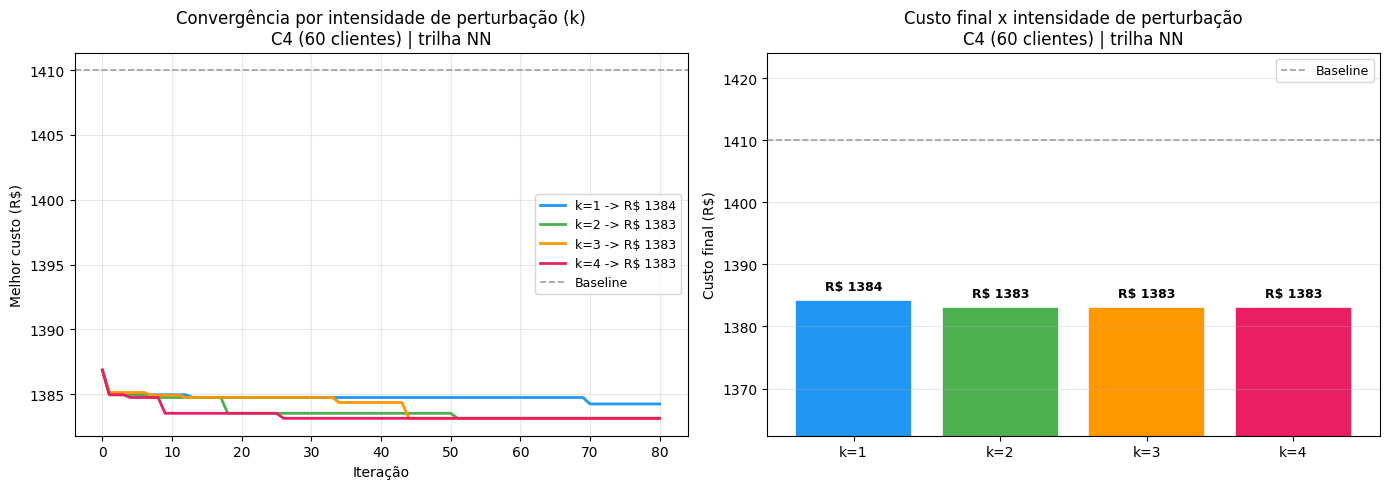

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
lista_cores = [CORES["k1"], CORES["k2"], CORES["k3"], CORES["k4"]]

ax = axes[0]
for idx, k in enumerate(K_VALORES):
    hist = resultados_k[k]["history"]
    ax.plot([h["iteration"] for h in hist], [h["best_cost"] for h in hist],
            color=lista_cores[idx], linewidth=2, label=f"k={k} -> R$ {resultados_k[k]['custo']:.0f}")
ax.axhline(custo_baseline, color=CORES["baseline"], linestyle="--", linewidth=1.2, label="Baseline")
ax.set_xlabel("Iteração")
ax.set_ylabel("Melhor custo (R$)")
ax.set_title(f"Convergência por intensidade de perturbação (k)\n{INSTANCIA_TRABALHO}")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
custos = [resultados_k[k]["custo"] for k in K_VALORES]
bars = ax2.bar([f"k={k}" for k in K_VALORES], custos, color=lista_cores, edgecolor="white", linewidth=1.2)
for bar, v in zip(bars, custos):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(custos) * 0.0008,
             f"R$ {v:.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax2.axhline(custo_baseline, color=CORES["baseline"], linestyle="--", linewidth=1.2, label="Baseline")
ax2.set_ylabel("Custo final (R$)")
ax2.set_title(f"Custo final x intensidade de perturbação\n{INSTANCIA_TRABALHO}")
ax2.set_ylim(min(custos) * 0.985, max(max(custos), custo_baseline) * 1.01)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "sensibilidade_k.png", dpi=150, bbox_inches="tight")
plt.show()

As curvas de convergência têm formatos coerentes com a teoria da intensidade, ainda que o custo final seja quase o mesmo. Todas despencam de R$ 1.410,00 para cerca de R$ 1.385,00 nas primeiras dez iterações — quase todo o ganho ocorre nesse trecho inicial. A diferença entre os `k` está na velocidade: `k=4` atinge o piso de R$ 1.383,14 por volta da iteração 10, enquanto `k=1` estaciona um degrau acima (R$ 1.384,25) e não consegue mais escapar até o fim. Perturbações mais intensas, portanto, alcançam o melhor ótimo local mais cedo, mas o teto de qualidade é compartilhado por todos os `k ≥ 2`. O painel de barras confirma a leitura: as quatro configurações ficam visivelmente abaixo do baseline e praticamente empatadas entre si.

### 1.2 Efeito do número de iterações `N`

Fixamos `k` no melhor valor da subseção anterior e variamos `N` em {20, 50, 100, 150, 200}. Como a semente é fixa, uma execução mais longa contém integralmente a trajetória de uma mais curta, o que torna o melhor custo monotonicamente não crescente em `N` e permite ler o ganho marginal de cada bloco adicional de iterações.

In [11]:
N_VALORES = [20, 50, 100, 150, 200]
K_ESCOLHIDO = melhor_k

resultados_N = {}
custo_anterior = custo_baseline

print(f"Experimento 2 — efeito de N | k={K_ESCOLHIDO} | perturbação={PERTURBACAO} | {INSTANCIA_TRABALHO}")
print(f"{'N':>4} | {'Custo final':>12} | {'Ganho vs BL':>12} | {'Tempo (s)':>10} | {'Ganho marginal':>15}")
print("-" * 70)

for N in N_VALORES:
    t0 = time.time()
    sol, hist = iterated_local_search(
        initial_solution=baseline_solution, D=D, q=q, s=s, params=params,
        perturbation_type=PERTURBACAO, perturbation_k=K_ESCOLHIDO,
        accept_criterion=ACCEPT, tolerance_pct=TOL,
        n_iterations=N, seed=SEED_FIXO, verbose=False,
    )
    elapsed = time.time() - t0
    custo = total_solution_cost(sol, D, params)
    ganho = (custo_baseline - custo) / custo_baseline * 100
    marginal = custo_anterior - custo
    resultados_N[N] = {"solution": sol, "history": hist, "custo": custo,
                       "ganho": ganho, "marginal": marginal, "tempo": elapsed}
    print(f"{N:>4} | R$ {custo:>9.2f} | {ganho:>10.2f}% | {elapsed:>9.2f} | R$ {marginal:>10.2f}")
    custo_anterior = custo

print("\nGanho marginal como % do custo baseline:")
for N in N_VALORES:
    mp = abs(resultados_N[N]["marginal"]) / custo_baseline * 100
    flag = "  <- retorno decrescente" if mp < 0.5 else ""
    print(f"  N={N:>3}: {mp:.3f}%{flag}")

Experimento 2 — efeito de N | k=2 | perturbação=double_bridge | C4 (60 clientes) | trilha NN
   N |  Custo final |  Ganho vs BL |  Tempo (s) |  Ganho marginal
----------------------------------------------------------------------


  20 | R$   1383.53 |       1.88% |      6.84 | R$      26.47


  50 | R$   1383.53 |       1.88% |     15.03 | R$       0.00


 100 | R$   1383.14 |       1.90% |     28.00 | R$       0.39


 150 | R$   1383.14 |       1.90% |     41.85 | R$       0.00


 200 | R$   1383.14 |       1.90% |     55.39 | R$       0.00

Ganho marginal como % do custo baseline:
  N= 20: 1.877%
  N= 50: 0.000%  <- retorno decrescente
  N=100: 0.027%  <- retorno decrescente
  N=150: 0.000%  <- retorno decrescente
  N=200: 0.000%  <- retorno decrescente


O retorno decrescente é acentuado e bem definido. Em apenas 20 iterações o ILS já alcança R$ 1.383,53 — uma redução de R$ 26,47 sobre o baseline, ou 1,88% dos 1,90% totais. O bloco de 20 a 50 iterações não acrescenta nada (ganho marginal de R$ 0,00). Entre 50 e 100 iterações surge uma única melhoria adicional de R$ 0,39 (0,027% do baseline), levando ao custo final de R$ 1.383,14. De 100 a 200 iterações, ganho marginal nulo.

A leitura operacional é direta: o ganho marginal cai abaixo de 0,5% do custo já a partir de N = 50, e não há nenhuma melhoria após N = 100. Em termos de tempo, N = 20 custa 6,8 s, N = 100 custa 28,0 s e N = 200 custa 55,4 s. Para a instância de trabalho, gastar mais de 100 iterações é desperdício de cálculo: dobrar o orçamento de 100 para 200 iterações não altera o resultado e apenas duplica o tempo.

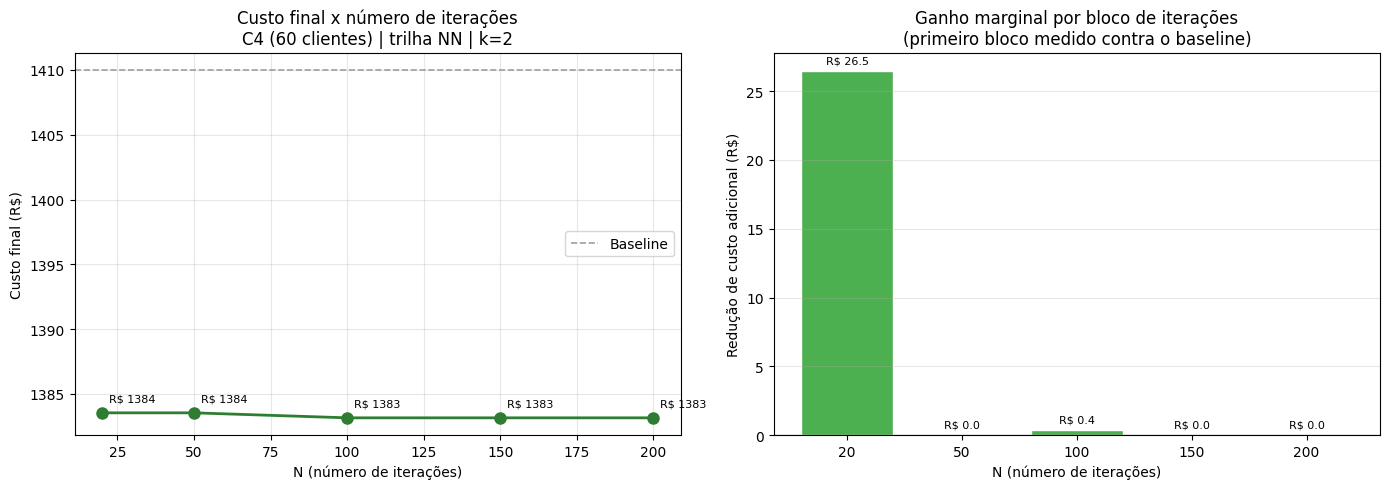

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ns = list(N_VALORES)
custos_N = [resultados_N[n]["custo"] for n in ns]

ax = axes[0]
ax.plot(ns, custos_N, "o-", color=CORES["ils"], linewidth=2, markersize=8)
ax.axhline(custo_baseline, color=CORES["baseline"], linestyle="--", linewidth=1.2, label="Baseline")
ax.set_xlabel("N (número de iterações)")
ax.set_ylabel("Custo final (R$)")
ax.set_title(f"Custo final x número de iterações\n{INSTANCIA_TRABALHO} | k={K_ESCOLHIDO}")
ax.legend()
ax.grid(True, alpha=0.3)
for x, y in zip(ns, custos_N):
    ax.annotate(f"R$ {y:.0f}", (x, y), textcoords="offset points", xytext=(5, 8), fontsize=8)

ax2 = axes[1]
marginais = [resultados_N[n]["marginal"] for n in ns]
ax2.bar([str(n) for n in ns], marginais, color=CORES["k2"], edgecolor="white")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_xlabel("N (número de iterações)")
ax2.set_ylabel("Redução de custo adicional (R$)")
ax2.set_title("Ganho marginal por bloco de iterações\n(primeiro bloco medido contra o baseline)")
ax2.grid(True, alpha=0.3, axis="y")
for i, v in enumerate(marginais):
    ax2.text(i, v + max(marginais) * 0.02, f"R$ {v:.1f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig(IMAGES_DIR / "sensibilidade_N.png", dpi=150, bbox_inches="tight")
plt.show()

O painel da esquerda mostra a curva de custo praticamente horizontal a partir de N = 20, sempre colada ao piso e distante do baseline tracejado. O painel da direita traduz isso em ganho marginal: uma barra única e dominante de R$ 26,5 no primeiro bloco, seguida de barras nulas ou desprezíveis. Visualmente, fica evidente que o orçamento de iterações relevante para esta instância é pequeno — a curva de aprendizado se esgota antes de N = 100.

Em síntese da Seção 1: o melhor `k` é 2, com sensibilidade fraca (qualquer `k ≥ 2` empata), e o `N` recomendado fica entre 50 e 100, pois além disso o ganho é nulo. Esses valores alimentam o diagnóstico de convergência e a recomendação operacional das próximas seções.

## Seção 2 — Diagnóstico de convergência

A curva de convergência conta onde o algoritmo melhorou, onde ficou preso e o que isso diz sobre a solução final. Falta a ela, porém, distinguir dois motivos para o ILS parar de melhorar. Na convergência genuína o algoritmo explorou bem o espaço e encontrou um bom ótimo local — mais iterações pouco ajudariam. Na estagnação prematura ele ficou preso num ótimo ruim porque a perturbação não foi forte o bastante para escapar — aí mais iterações, com perturbação mais agressiva, poderiam ajudar.

A distinção se faz observando quando ocorreu a última melhoria e o que acontece com o custo corrente depois dela. Se a última melhoria foi na iteração 12 de 150, o algoritmo passou 138 iterações sem progredir — estagnação. Se foi na iteração 145, ainda estava aprendendo quando o orçamento acabou. Rodamos o diagnóstico com a configuração da Equipe 2 (double-bridge + estrito), usando o `k` ótimo da Seção 1 e N = 150 iterações.

In [13]:
CONFIG_EQUIPE = dict(
    perturbation_type=PERTURBACAO, perturbation_k=K_ESCOLHIDO,
    accept_criterion=ACCEPT, tolerance_pct=TOL,
)
N_DIAG = 150

sol_diag, hist_diag = iterated_local_search(
    initial_solution=baseline_solution, D=D, q=q, s=s, params=params,
    n_iterations=N_DIAG, seed=SEED_FIXO, verbose=False, **CONFIG_EQUIPE,
)

df_hist = pd.DataFrame(hist_diag)
df_hist["nova_melhor"] = df_hist["best_cost"] < df_hist["best_cost"].shift(1, fill_value=float("inf"))
melhorias = df_hist[df_hist["nova_melhor"]]

custo_inicial = df_hist.iloc[0]["current_cost"]      # custo já refinado pela busca local na iteração 0
custo_final = df_hist.iloc[-1]["best_cost"]
n_melhorias = max(len(melhorias) - 1, 0)
ultima_melhora = int(melhorias.iloc[-1]["iteration"]) if len(melhorias) > 1 else 0
ganho_total = (custo_inicial - custo_final) / custo_inicial * 100
pct_ociosa = (N_DIAG - ultima_melhora) / N_DIAG * 100
ganho_vs_baseline = (custo_baseline - custo_final) / custo_baseline * 100

print(f"Configuração Equipe 2 | {INSTANCIA_TRABALHO} | k={K_ESCOLHIDO} | N={N_DIAG}")
print("-" * 60)
print(f"Custo baseline (busca local Aula 8) : R$ {custo_baseline:.2f}")
print(f"Custo na iteração 0 (após 2-opt+Reloc): R$ {custo_inicial:.2f}")
print(f"Custo final ILS                      : R$ {custo_final:.2f}")
print(f"Ganho metaheurístico (iter 0 -> fim) : {ganho_total:.2f}%")
print(f"Ganho total vs baseline              : {ganho_vs_baseline:.2f}%")
print(f"Número de melhorias                  : {n_melhorias}")
print(f"Última melhoria                      : iteração {ultima_melhora} / {N_DIAG}")
print(f"Iterações sem melhoria               : {N_DIAG - ultima_melhora} ({pct_ociosa:.0f}% do total)")

if pct_ociosa > 50:
    diagnostico = "ESTAGNAÇÃO — o algoritmo parou de melhorar cedo."
elif pct_ociosa > 25:
    diagnostico = "CONVERGÊNCIA PARCIAL — há alguma estagnação."
else:
    diagnostico = "CONVERGÊNCIA ATIVA — ainda melhorava perto do fim."
print(f"\nDiagnóstico automático: {diagnostico}")

Configuração Equipe 2 | C4 (60 clientes) | trilha NN | k=2 | N=150
------------------------------------------------------------
Custo baseline (busca local Aula 8) : R$ 1410.00
Custo na iteração 0 (após 2-opt+Reloc): R$ 1386.86
Custo final ILS                      : R$ 1383.14
Ganho metaheurístico (iter 0 -> fim) : 0.27%
Ganho total vs baseline              : 1.90%
Número de melhorias                  : 4
Última melhoria                      : iteração 51 / 150
Iterações sem melhoria               : 99 (66% do total)

Diagnóstico automático: ESTAGNAÇÃO — o algoritmo parou de melhorar cedo.


O diagnóstico confirma a decomposição antecipada na Seção 1. Dos 1,90% de ganho total sobre o baseline, a maior parte vem da busca local reaplicada na iteração 0: o 2-opt + Relocate sobre a solução da Aula 8 derruba o custo de R$ 1.410,00 para R$ 1.386,86 (R$ 23,14, ou 1,64%). O ganho propriamente metaheurístico — o que as perturbações double-bridge acrescentam da iteração 0 ao fim — é de apenas R$ 3,72, 0,27%. Foram quatro melhorias ao longo das 150 iterações, a última na iteração 51, deixando 99 iterações (66%) sem progresso.

A regra automática classifica isso como estagnação por ultrapassar 50% de iterações ociosas, mas o cruzamento com a Seção 1 corrige a leitura. Não se trata de uma armadilha que mais iterações ou perturbações mais fortes resolveriam: a análise de `N` mostrou ganho nulo de N = 100 a N = 200, e a análise de `k` mostrou que intensificar a perturbação (k = 4) não melhora o resultado. O algoritmo, portanto, atingiu convergência genuína para esta vizinhança por volta da iteração 51 — esgotou o que double-bridge + 2-opt + Relocate conseguem extrair de C4-NN, e não há sinal de que esteja preso num ótimo ruim escapável. A fração ociosa elevada é consequência do orçamento de 150 iterações ser muito maior do que o necessário, não de uma falha de exploração.

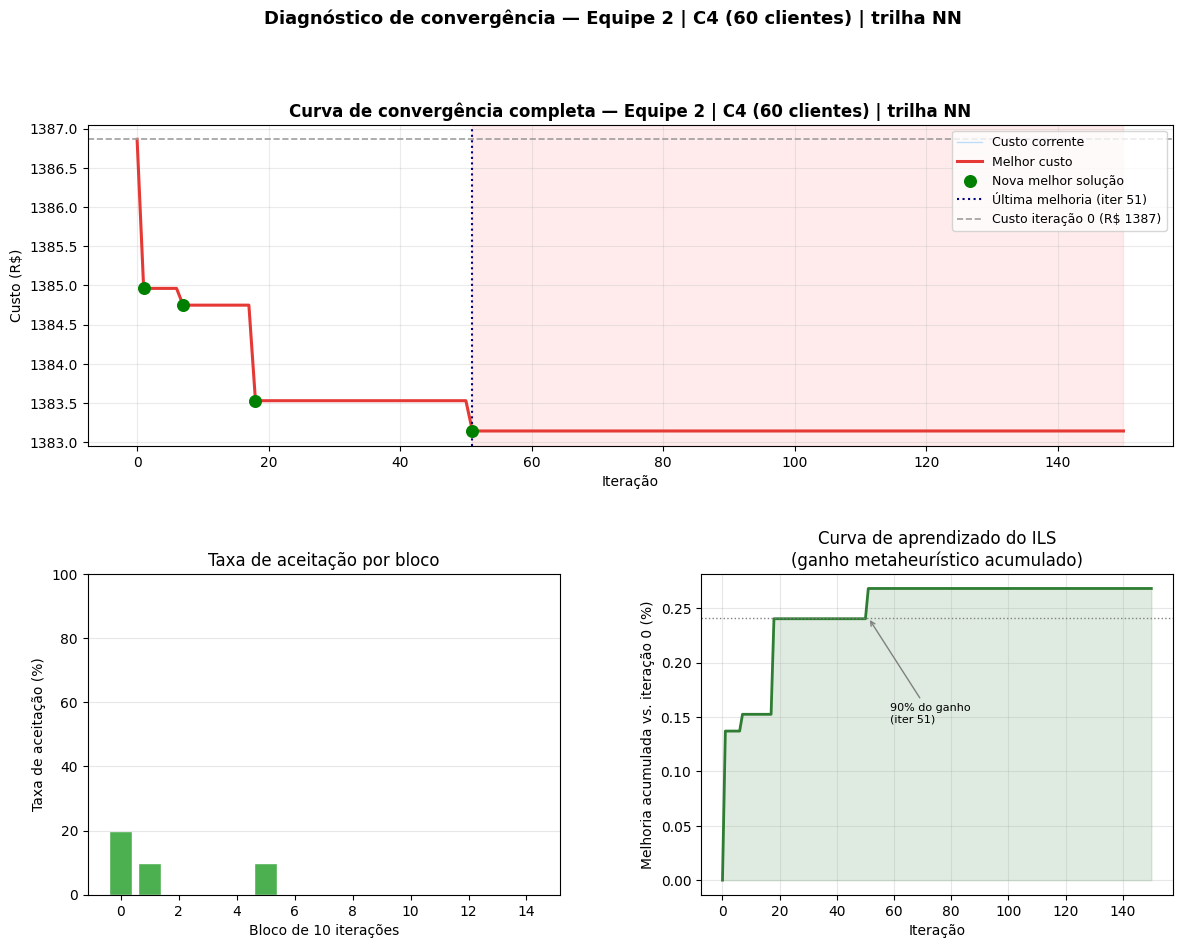

90% do ganho metaheurístico atingido na iteração 51 de 150.


In [14]:
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

iters = df_hist["iteration"].values
currnt = df_hist["current_cost"].values
best = df_hist["best_cost"].values

# Painel 1 — curva de convergência completa
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(iters, currnt, color=CORES["atual"], alpha=0.6, linewidth=1.0, label="Custo corrente")
ax1.plot(iters, best, color=CORES["melhor"], linewidth=2.2, label="Melhor custo")
if len(melhorias) > 1:
    ax1.scatter(melhorias["iteration"].iloc[1:], melhorias["best_cost"].iloc[1:],
                color="green", s=70, zorder=5, label="Nova melhor solução")
ax1.axvline(ultima_melhora, color="navy", linestyle=":", linewidth=1.5,
            label=f"Última melhoria (iter {ultima_melhora})")
ax1.axhline(custo_inicial, color=CORES["baseline"], linestyle="--", linewidth=1.2,
            label=f"Custo iteração 0 (R$ {custo_inicial:.0f})")
ax1.axvspan(ultima_melhora, N_DIAG, alpha=0.08, color="red")
ax1.set_xlabel("Iteração")
ax1.set_ylabel("Custo (R$)")
ax1.set_title(f"Curva de convergência completa — Equipe 2 | {INSTANCIA_TRABALHO}", fontweight="bold")
ax1.legend(fontsize=9, loc="upper right")
ax1.grid(True, alpha=0.25)

# Painel 2 — taxa de aceitação por bloco de 10 iterações
ax2 = fig.add_subplot(gs[1, 0])
bloco = 10
df_ls = df_hist[df_hist["iteration"] > 0].copy()
df_ls["bloco"] = (df_ls["iteration"] - 1) // bloco
taxa = df_ls.groupby("bloco")["accepted"].mean() * 100
ax2.bar(taxa.index, taxa.values, color=CORES["k2"], edgecolor="white")
ax2.set_xlabel(f"Bloco de {bloco} iterações")
ax2.set_ylabel("Taxa de aceitação (%)")
ax2.set_title("Taxa de aceitação por bloco")
ax2.set_ylim(0, 100)
ax2.grid(True, alpha=0.3, axis="y")

# Painel 3 — ganho acumulado vs. custo da iteração 0
ax3 = fig.add_subplot(gs[1, 1])
melhoria_acum = (custo_inicial - best) / custo_inicial * 100
ax3.plot(iters, melhoria_acum, color=CORES["ils"], linewidth=2)
ax3.fill_between(iters, 0, melhoria_acum, alpha=0.15, color=CORES["ils"])
ax3.set_xlabel("Iteração")
ax3.set_ylabel("Melhoria acumulada vs. iteração 0 (%)")
ax3.set_title("Curva de aprendizado do ILS\n(ganho metaheurístico acumulado)")
ax3.grid(True, alpha=0.3)
if melhoria_acum.max() > 0:
    ganho_90 = melhoria_acum.max() * 0.90
    iter_90 = int(iters[np.argmax(melhoria_acum >= ganho_90)])
    ax3.axhline(ganho_90, color="gray", linestyle=":", linewidth=1)
    ax3.annotate(f"90% do ganho\n(iter {iter_90})", (iter_90, ganho_90),
                 xytext=(iter_90 + max(N_DIAG * 0.05, 1), ganho_90 * 0.6),
                 fontsize=8, arrowprops=dict(arrowstyle="->", color="gray"))
else:
    iter_90 = 0

plt.suptitle(f"Diagnóstico de convergência — Equipe 2 | {INSTANCIA_TRABALHO}",
             fontsize=13, fontweight="bold", y=0.995)
plt.savefig(IMAGES_DIR / "diagnostico_convergencia.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"90% do ganho metaheurístico atingido na iteração {iter_90} de {N_DIAG}.")

O painel superior mostra um descida em quatro degraus: o melhor custo cai de R$ 1.386,86 para R$ 1.385,0 (iteração 1), R$ 1.384,75 (iteração 7), R$ 1.383,53 (iteração 18) e R$ 1.383,14 (iteração 51), estabilizando daí em diante. A faixa vermelha cobre as 99 iterações ociosas após a última melhoria. A linha de custo corrente praticamente coincide com a de melhor custo porque o critério estrito só aceita reduções — sob aceitação estrita, a solução corrente nunca piora, então as duas curvas se sobrepõem.

O painel inferior esquerdo confirma o padrão: aceitações ocorrem apenas nos blocos iniciais (cerca de 20% no bloco 0, 10% nos blocos 1 e 5) e zeram completamente depois do bloco 5. A taxa de aceitação cai a zero não por exploração de regiões de custo parecido, mas porque o critério estrito rejeita tudo que não melhora, e melhorias deixam de aparecer após a iteração 51. O painel inferior direito fecha a leitura: a curva de aprendizado metaheurístico sobe em degraus até o teto de 0,27% e satura exatamente na iteração 51, onde os 90% do ganho são atingidos. Confirma-se que, para esta instância, um orçamento de 50 a 60 iterações basta — tudo além disso é tempo de cálculo sem retorno.

### 2.2 Critério de aceitação: estrito × tolerância

A Equipe 2 adota o critério estrito, mas vale medir o que se perde ou se ganha ao permitir pioras controladas. O critério de tolerância aceita soluções até 3% piores que a corrente, na esperança de que oscilar para regiões piores ajude a escapar de ótimos locais. Comparamos as duas configurações com a mesma perturbação, o mesmo `k` e N = 150.

In [15]:
resultados_aceit = {}

for criterio, delta in [("strict", 0.0), ("tolerance", 0.03)]:
    _, hist = iterated_local_search(
        initial_solution=baseline_solution, D=D, q=q, s=s, params=params,
        perturbation_type=PERTURBACAO, perturbation_k=K_ESCOLHIDO,
        accept_criterion=criterio, tolerance_pct=delta,
        n_iterations=N_DIAG, seed=SEED_FIXO, verbose=False,
    )
    resultados_aceit[criterio] = pd.DataFrame(hist)

print(f"Critério     | Custo final | Ganho vs iter 0 | Taxa de aceitação")
print("-" * 62)
for criterio in ["strict", "tolerance"]:
    dfp = resultados_aceit[criterio]
    cf = dfp.iloc[-1]["best_cost"]
    g = (custo_inicial - cf) / custo_inicial * 100
    ta = dfp[dfp["iteration"] > 0]["accepted"].mean() * 100
    print(f"{criterio:<12} | R$ {cf:>8.2f} | {g:>13.2f}% | {ta:>15.1f}%")

Critério     | Custo final | Ganho vs iter 0 | Taxa de aceitação
--------------------------------------------------------------
strict       | R$  1383.14 |          0.27% |             2.7%
tolerance    | R$  1383.53 |          0.24% |           100.0%


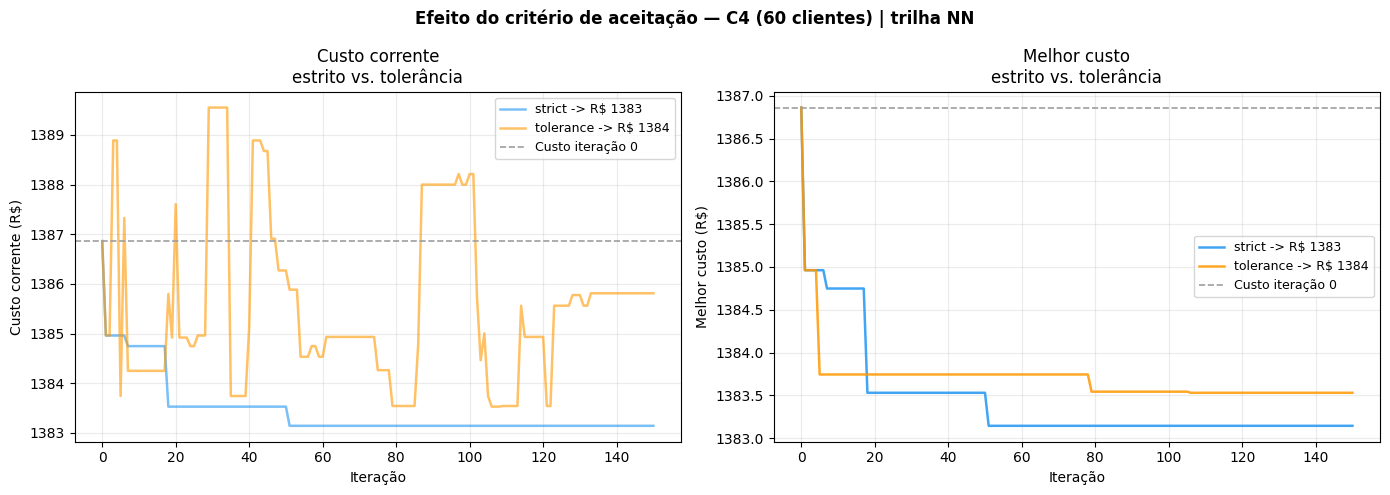

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, label in [(axes[0], "current_cost", "Custo corrente"),
                       (axes[1], "best_cost", "Melhor custo")]:
    for criterio, cor in [("strict", CORES["k1"]), ("tolerance", CORES["k3"])]:
        dfp = resultados_aceit[criterio]
        cf = dfp.iloc[-1]["best_cost"]
        ax.plot(dfp["iteration"], dfp[col], color=cor, linewidth=1.8,
                alpha=0.85 if col == "best_cost" else 0.6,
                label=f"{criterio} -> R$ {cf:.0f}")
    ax.axhline(custo_inicial, color=CORES["baseline"], linestyle="--", linewidth=1.2,
               label="Custo iteração 0")
    ax.set_xlabel("Iteração")
    ax.set_ylabel(f"{label} (R$)")
    ax.set_title(f"{label}\nestrito vs. tolerância")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)

plt.suptitle(f"Efeito do critério de aceitação — {INSTANCIA_TRABALHO}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "comparacao_criterios.png", dpi=150, bbox_inches="tight")
plt.show()

A comparação favorece o critério estrito da Equipe 2. O painel da esquerda mostra a diferença de regime: o estrito (azul) desce em degraus e fica imóvel no piso de R$ 1.383,14, enquanto a tolerância (laranja) oscila entre R$ 1.383,5 e R$ 1.389,5, subindo várias vezes acima do custo da iteração 0. Essa oscilação é o random walk esperado de um critério que aceita 100% dos candidatos — como a busca local repara cada perturbação, nenhum candidato fica mais de 3% pior que a solução corrente, e tudo é aceito.

O ponto decisivo está no painel da direita: a oscilação da tolerância não se converteu em melhor solução. O melhor custo do estrito termina em R$ 1.383,14, abaixo dos R$ 1.383,53 da tolerância. A exploração mais agressiva foi ruído sem benefício nesta instância — coerente com o diagnóstico de que C4-NN já converge genuinamente, sem ótimos locais ruins dos quais a tolerância precisaria escapar. Para o perfil de instâncias da Prolog, o critério estrito entrega resultado igual ou melhor com trajetória estável e previsível, o que sustenta a escolha da equipe.

## Seção 3 — Escalabilidade: o ILS funciona igual em instâncias maiores?

A demanda diária da Prolog varia, e o algoritmo precisa funcionar bem em diferentes escalas. A escalabilidade responde a duas perguntas práticas: o ganho do ILS cresce ou encolhe com o número de clientes, e o tempo de cálculo cresce de forma aceitável. A teoria sugere que em instâncias pequenas a busca local já encontra bons ótimos por conta própria, sobrando pouco para a metaheurística; em instâncias maiores, com espaço de soluções muito maior e ótimos locais mais distantes, a perturbação ganharia valor.

Rodamos o ILS da Equipe 2 sobre as quatro instâncias C1–C4 na trilha NN, com `k` = 2 e N = 80. Como a Seção 2 mostrou que o ganho contra o baseline carregado mistura o refinamento da busca local na iteração 0 com o ganho metaheurístico, registramos as duas parcelas em separado: o ganho total sobre a solução da Aula 8 e o ganho metaheurístico puro a partir do custo já refinado na iteração 0.

### 3.1 Execução do ILS nas quatro instâncias

In [17]:
N_ESCALA = 80
HEUR_ESCALA = "NN"

resultados_escala = []

for nome_inst in INSTANCIAS:
    inst = INST[nome_inst]
    D_i, q_i, s_i, params_i = inst["D"], inst["q"], inst["s"], inst["params"]
    sol_bl_i = INITIAL_SOLUTIONS[HEUR_ESCALA][nome_inst]
    n_cli = inst["n_clientes"]

    c_bl = total_solution_cost(sol_bl_i, D_i, params_i)

    t0 = time.time()
    sol_ils_i, hist_i = iterated_local_search(
        initial_solution=sol_bl_i, D=D_i, q=q_i, s=s_i, params=params_i,
        n_iterations=N_ESCALA, seed=SEED_FIXO, verbose=False, **CONFIG_EQUIPE,
    )
    t_ils = time.time() - t0

    c_iter0 = hist_i[0]["current_cost"]
    c_ils = total_solution_cost(sol_ils_i, D_i, params_i)
    ganho_total = (c_bl - c_ils) / c_bl * 100
    ganho_meta = (c_iter0 - c_ils) / c_iter0 * 100

    resultados_escala.append({
        "instancia": nome_inst, "n_clientes": n_cli,
        "custo_bl": c_bl, "custo_iter0": c_iter0, "custo_ils": c_ils,
        "ganho_total_pct": ganho_total, "ganho_meta_pct": ganho_meta,
        "t_ils": t_ils,
        "feasible_ils": is_solution_feasible(sol_ils_i, D_i, q_i, s_i, params_i),
        "history": hist_i, "solution_ils": sol_ils_i,
    })

df_escala = pd.DataFrame([{k: v for k, v in r.items() if k not in ("history", "solution_ils")}
                          for r in resultados_escala])
display(df_escala.set_index("instancia").round(
    {"custo_bl": 2, "custo_iter0": 2, "custo_ils": 2,
     "ganho_total_pct": 2, "ganho_meta_pct": 3, "t_ils": 2}))

,n_clientes,custo_bl,custo_iter0,custo_ils,ganho_total_pct,ganho_meta_pct,t_ils,feasible_ils
instancia,,,,,,,,
C1,10,422.38,422.38,422.38,0.00,0.000,0.15,True
C2,25,712.49,710.47,710.47,0.28,0.000,2.12,True
C3,40,1043.69,779.76,775.01,25.74,0.609,3.67,True
C4,60,1410.00,1386.86,1383.14,1.90,0.268,22.93,True


A tabela separa com nitidez os dois efeitos e desfaz uma interpretação ingênua. O ganho total sobre o baseline é errático: 0,00% em C1, 0,28% em C2, 25,74% em C3 e 1,90% em C4. O salto de C3 não vem da metaheurística — vem do fato de que a solução NN-C3 salva na Aula 8 estava mal refinada (R$ 1.043,69), e o 2-opt + Relocate reaplicado na iteração 0 a derruba para R$ 779,76. É o mesmo achado de não idempotência documentado na Aula 11, agora quantificado: o Swap aplicado por último na Aula 8 deixou a rota NN-C3 numa configuração que o 2-opt + Relocate melhora em 25%.

O ganho metaheurístico puro, medido a partir do custo já refinado da iteração 0, é pequeno em todas as instâncias: 0,00% (C1), 0,00% (C2), 0,609% (C3) e 0,268% (C4). Ele não cresce monotonicamente com o número de clientes — o pico está em C3 (40 clientes), não em C4 (60). A hipótese de que o ILS se torna mais valioso em instâncias maiores não se confirma para esta base: a busca local já resolve a maior parte do problema, e o que sobra para as perturbações é marginal. O tempo, por outro lado, cresce de forma acentuada — de 0,15 s em C1 para 22,93 s em C4. O salto de C3 (3,67 s) para C4 (22,93 s) é de cerca de seis vezes para 1,5 vez mais clientes, sinal do custo super-linear do Relocate, que reavalia a solução inteira a cada movimento candidato. Todas as soluções permanecem viáveis.

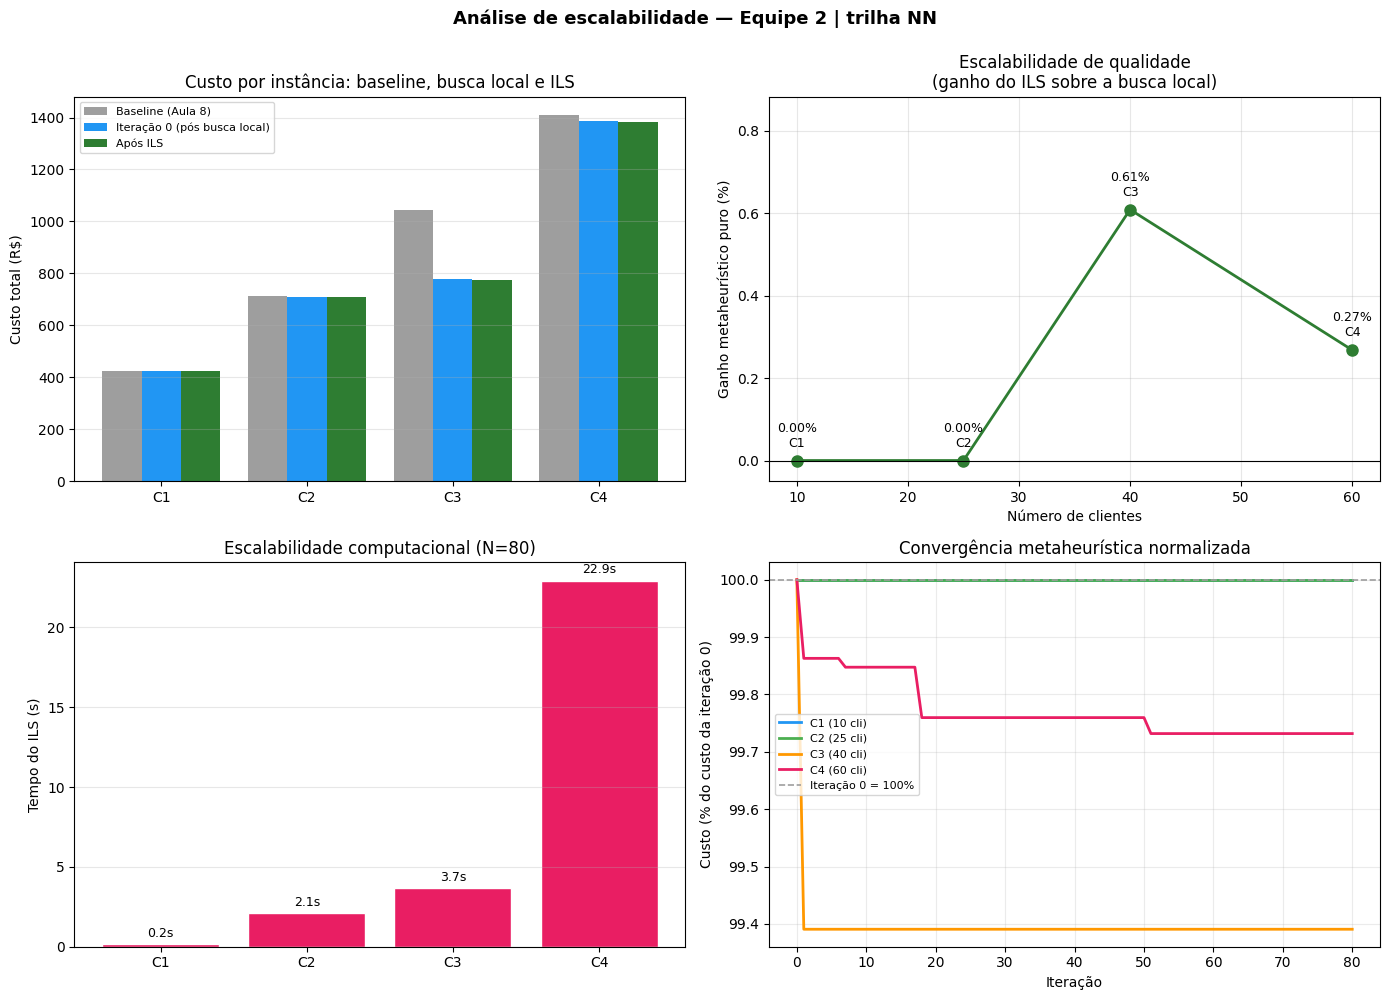

In [18]:
resultados_escala = sorted(resultados_escala, key=lambda r: r["n_clientes"])
xs = [r["instancia"] for r in resultados_escala]
ns = np.array([r["n_clientes"] for r in resultados_escala])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Painel 1 — custos: baseline, iteração 0 (pós busca local) e ILS
ax = axes[0, 0]
x = np.arange(len(xs))
w = 0.27
ax.bar(x - w, [r["custo_bl"] for r in resultados_escala], w, label="Baseline (Aula 8)", color=CORES["baseline"])
ax.bar(x, [r["custo_iter0"] for r in resultados_escala], w, label="Iteração 0 (pós busca local)", color=CORES["k1"])
ax.bar(x + w, [r["custo_ils"] for r in resultados_escala], w, label="Após ILS", color=CORES["ils"])
ax.set_xticks(x)
ax.set_xticklabels(xs)
ax.set_ylabel("Custo total (R$)")
ax.set_title("Custo por instância: baseline, busca local e ILS")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis="y")

# Painel 2 — ganho metaheurístico vs número de clientes
ax = axes[0, 1]
gm = [r["ganho_meta_pct"] for r in resultados_escala]
ax.plot(ns, gm, "o-", color=CORES["ils"], linewidth=2, markersize=8)
for x_p, y_p, inst in zip(ns, gm, xs):
    ax.annotate(f"{y_p:.2f}%\n{inst}", (x_p, y_p), textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=9)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Número de clientes")
ax.set_ylabel("Ganho metaheurístico puro (%)")
ax.set_title("Escalabilidade de qualidade\n(ganho do ILS sobre a busca local)")
ax.set_ylim(-0.05, max(gm) * 1.45)
ax.grid(True, alpha=0.3)

# Painel 3 — tempo computacional
ax = axes[1, 0]
ts = [r["t_ils"] for r in resultados_escala]
ax.bar(xs, ts, color=CORES["k4"], edgecolor="white")
ax.set_ylabel("Tempo do ILS (s)")
ax.set_title(f"Escalabilidade computacional (N={N_ESCALA})")
ax.grid(True, alpha=0.3, axis="y")
for i, v in enumerate(ts):
    ax.text(i, v + max(ts) * 0.02, f"{v:.1f}s", ha="center", fontsize=9)

# Painel 4 — convergência metaheurística normalizada pelo custo da iteração 0
ax = axes[1, 1]
paleta = [CORES["k1"], CORES["k2"], CORES["k3"], CORES["k4"]]
for idx, r in enumerate(resultados_escala):
    dfh = pd.DataFrame(r["history"])
    ax.plot(dfh["iteration"], dfh["best_cost"] / r["custo_iter0"] * 100,
            color=paleta[idx % len(paleta)], linewidth=2,
            label=f"{r['instancia']} ({r['n_clientes']} cli)")
ax.axhline(100, color=CORES["baseline"], linestyle="--", linewidth=1.2, label="Iteração 0 = 100%")
ax.set_xlabel("Iteração")
ax.set_ylabel("Custo (% do custo da iteração 0)")
ax.set_title("Convergência metaheurística normalizada")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)

plt.suptitle("Análise de escalabilidade — Equipe 2 | trilha NN", fontsize=13, fontweight="bold", y=0.995)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "escalabilidade.png", dpi=150, bbox_inches="tight")
plt.show()

Os quatro quadros consolidam a leitura. No painel de custos, C1 e C2 têm as três barras praticamente idênticas — não há o que melhorar além da busca local. C3 exibe o degrau característico entre o baseline cinza e a barra da iteração 0, a marca visual da reaplicação do 2-opt + Relocate; já a contribuição do ILS (azul para verde) é imperceptível na escala da figura em todas as instâncias.

O painel de qualidade mostra que o ganho metaheurístico não escala com o tamanho: ele é nulo até 25 clientes, atinge o pico de 0,61% em C3 (40 clientes) e recua para 0,27% em C4 (60 clientes). A curva tem forma de corcova, não de rampa — refuta, para esta base, a hipótese de que o ILS se torna progressivamente mais valioso em instâncias maiores. O painel de tempo conta a história oposta e mais preocupante: o custo computacional cresce de forma super-linear, de 0,15 s em C1 para 22,9 s em C4, com o salto abrupto entre C3 e C4. O painel de convergência normalizada confirma que mesmo a maior descida metaheurística (C3, até 99,39% do custo da iteração 0) é modesta, e que toda a ação ocorre nas primeiras dezenas de iterações. A conclusão operacional é que, com a configuração atual, a restrição determinante para a Prolog é tempo, não qualidade — e o gargalo está no Relocate aplicado a instâncias grandes.

## Seção 4 — Síntese e recomendação para a operação

A pergunta de abertura era como o ILS se comporta. As três análises convergem para uma resposta consistente. Sobre os parâmetros, a sensibilidade a `k` é fraca — qualquer `k ≥ 2` empata no melhor custo, com `k = 2` à frente por uma margem desprezível — e o `N` tem retorno decrescente abrupto: 20 iterações já capturam 1,88% dos 1,90% de ganho total em C4, e não há melhoria alguma além de 100 iterações. Sobre a convergência, o algoritmo atinge convergência genuína por volta da iteração 51 na instância de trabalho; a fração ociosa elevada reflete um orçamento de iterações maior do que o necessário, não uma armadilha de ótimo local, conforme confirmado pela ausência de ganho ao aumentar `N` ou `k`. O critério estrito da equipe iguala ou supera a tolerância de 3%, que apenas oscila sem benefício.

A descoberta central, porém, é a decomposição do ganho. O que parecia ganho do ILS é, em sua quase totalidade, o refinamento da busca local reaplicada na iteração 0: o ganho metaheurístico puro fica entre 0,00% e 0,61% nas quatro instâncias e não cresce com o tamanho do problema. O ILS não é o motor da economia — a busca local é. O papel da metaheurística é um polimento final modesto e barato em instâncias pequenas, que se torna caro em instâncias grandes pelo custo super-linear do Relocate (22,9 s em C4 contra 3,7 s em C3).

Recomendação para a operação diária da Prolog (questão 9). Manter o pipeline Nearest Neighbor + busca local 2-opt + Relocate + Swap como base, e ativar o ILS com a configuração da Equipe 2 — double-bridge, aceitação estrita, `k = 2` — limitando o orçamento a `N = 50` a `100` iterações. Essa faixa esgota o ganho disponível e mantém o tempo na casa de dezenas de segundos para instâncias de até 60 clientes. Gastar mais iterações é desperdício de cálculo comprovado.

Cenários para configuração distinta (questão 10). Sob urgência de roteamento, `N = 20` entrega 98,6% do ganho em C4 em apenas 6,8 s — vale reduzir o orçamento quando o plano precisa sair em segundos. Para instâncias substancialmente maiores que C4, como a instância de competição, o gargalo deixa de ser o número de iterações e passa a ser o tempo por iteração: aí convém manter `N` baixo e, se necessário, restringir a vizinhança do Relocate, sem trocar o critério de aceitação, já que a tolerância não trouxe ganho nesta base.

### 4.1 Salvamento de artefatos

As tabelas das análises e as soluções finais do ILS são gravadas em `files/` para alimentar o relatório consolidado da Sprint 3; as quatro figuras já foram salvas em `images/` ao longo do notebook. São exportações justificadas por consumo externo (o relatório), não armazenamento de resultados intermediários.

In [19]:
salvos = []

# Tabela de sensibilidade a k (instância de trabalho)
df_k = pd.DataFrame([
    {"k": k, "custo_final": resultados_k[k]["custo"],
     "ganho_total_pct": resultados_k[k]["ganho"], "tempo_s": resultados_k[k]["tempo"]}
    for k in K_VALORES
])
p = OUTPUT_FILES_DIR / "sensibilidade_k_C4.csv"
df_k.to_csv(p, index=False); salvos.append(p)

# Tabela de sensibilidade a N
df_n = pd.DataFrame([
    {"N": N, "custo_final": resultados_N[N]["custo"], "ganho_total_pct": resultados_N[N]["ganho"],
     "ganho_marginal_rs": resultados_N[N]["marginal"], "tempo_s": resultados_N[N]["tempo"]}
    for N in N_VALORES
])
p = OUTPUT_FILES_DIR / "sensibilidade_N_C4.csv"
df_n.to_csv(p, index=False); salvos.append(p)

# Histórico de convergência do diagnóstico (instância de trabalho)
p = OUTPUT_FILES_DIR / "historico_diagnostico_C4.csv"
df_hist.drop(columns=["nova_melhor"]).to_csv(p, index=False); salvos.append(p)

# Tabela de escalabilidade
p = OUTPUT_FILES_DIR / "escalabilidade_C1_C4.csv"
df_escala.to_csv(p, index=False); salvos.append(p)

# Soluções finais do ILS por instância (trilha NN, k=2)
for r in resultados_escala:
    inst = r["instancia"]
    D_i, q_i, s_i, params_i = INST[inst]["D"], INST[inst]["q"], INST[inst]["s"], INST[inst]["params"]
    payload = {
        "equipe": "Equipe 2 (Grupo 2)",
        "heuristic_initial": HEUR_ESCALA,
        "instance": inst,
        "perturbation_type": PERTURBACAO,
        "accept_criterion": ACCEPT,
        "perturbation_k": K_ESCOLHIDO,
        "n_iterations": N_ESCALA,
        "seed": SEED_FIXO,
        "solution": r["solution_ils"],
        "metrics": solution_metrics(r["solution_ils"], D_i, q_i, s_i, params_i),
        "custo_baseline": r["custo_bl"],
        "custo_ils": r["custo_ils"],
        "elapsed_sec": r["t_ils"],
    }
    p = OUTPUT_FILES_DIR / f"solution_ils_sens_nn_{inst}.json"
    p.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")
    salvos.append(p)

print("Arquivos salvos em files/:")
for p in salvos:
    print(" -", p.name)
print(f"\nImagens em images/: {[f.name for f in sorted(IMAGES_DIR.glob('*.png'))]}")

Arquivos salvos em files/:
 - sensibilidade_k_C4.csv
 - sensibilidade_N_C4.csv
 - historico_diagnostico_C4.csv
 - escalabilidade_C1_C4.csv
 - solution_ils_sens_nn_C1.json
 - solution_ils_sens_nn_C2.json
 - solution_ils_sens_nn_C3.json
 - solution_ils_sens_nn_C4.json

Imagens em images/: ['comparacao_criterios.png', 'diagnostico_convergencia.png', 'escalabilidade.png', 'notebook_23_0.png', 'notebook_28_0.png', 'notebook_33_0.png', 'notebook_37_0.png', 'notebook_42_0.png', 'sensibilidade_k.png', 'sensibilidade_N.png']


# Aula 12 — Análise de Comportamento do ILS para o CVRP da Prolog

**ENG 4560 — Projeto Integrado VI: Distribuição Física | Grupo 2**

Na Aula 11 o Iterated Local Search (ILS) foi implementado e produziu a primeira solução melhorada para as instâncias C1–C4. A pergunta deixa de ser *o algoritmo funciona?* e passa a ser *como ele se comporta?*. Este notebook responde a essa pergunta em três frentes, todas com implicação direta na recomendação operacional para a Prolog e na configuração a levar para a instância de competição da Sprint 3.

A configuração da Equipe 2, fixada no Sprint Planning #3, orienta toda a análise: perturbação **double-bridge**, critério de aceitação **estrito**, busca local **2-opt + Relocate** e semente 42. O estudo se organiza assim: (1) sensibilidade aos parâmetros `k` (intensidade da perturbação) e `N` (número de iterações); (2) diagnóstico de convergência, distinguindo convergência genuína de estagnação prematura; (3) escalabilidade ao longo das quatro instâncias C1–C4. A instância de trabalho das Seções 1 e 2 é a **C4** (60 clientes, trilha Nearest Neighbor), a maior e mais estruturada da base, onde o ILS da Aula 11 ainda melhorava perto do fim do orçamento de iterações.

Os dados e a biblioteca de funções reproduzem o código de referência da Aula 12 do professor; a única diferença é o carregamento direto dos arquivos locais (instâncias da Aula 2 e soluções pós-busca-local da Aula 8), sem o `upload` do Colab.

## Seção 0 — Ambiente, dados e biblioteca de funções

Esta seção prepara tudo o que as análises consomem: importações, caminhos relativos para os dados, carregamento das quatro instâncias C1–C4 (Aula 2) e das soluções pós-busca-local (Aula 8), e a biblioteca de avaliação, busca local, perturbação e ILS. As funções são as mesmas da Aula 11, acrescidas do parâmetro `k` nas perturbações — sem essa intensidade variável a análise de sensibilidade da Seção 1 não existiria.

### 0.1 Importações e caminhos

In [1]:
import copy
import json
import random
import time

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from IPython.display import display

DATASETS_DIR = Path("../../2/datasets")
SOLUTIONS_BL_DIR = Path("../../8/Aula8_Busca_Local/files")
OUTPUT_FILES_DIR = Path("files")
OUTPUT_FILES_DIR.mkdir(exist_ok=True)
IMAGES_DIR = Path("images")
IMAGES_DIR.mkdir(exist_ok=True)

INSTANCIAS = {
    "C1": "Equipe_2_C1_10",
    "C2": "Equipe_2_C2_25",
    "C3": "Equipe_2_C3_40",
    "C4": "Equipe_2_C4_60",
}
HEURISTICAS = ["NN", "CW"]

# Paleta padronizada das curvas e barras (mesma do código de referência da Aula 12).
CORES = {
    "k1": "#2196F3", "k2": "#4CAF50", "k3": "#FF9800", "k4": "#E91E63",
    "melhor": "#E53935", "atual": "#90CAF9", "baseline": "#9E9E9E", "ils": "#2E7D32",
}

assert DATASETS_DIR.exists(), f"Diretório de instâncias não encontrado: {DATASETS_DIR.resolve()}"
assert SOLUTIONS_BL_DIR.exists(), f"Diretório de soluções pós-BL não encontrado: {SOLUTIONS_BL_DIR.resolve()}"

print("Datasets (Aula 2):       ", DATASETS_DIR.resolve())
print("Soluções pós-BL (Aula 8):", SOLUTIONS_BL_DIR.resolve())
print("Instâncias:", list(INSTANCIAS.keys()))

Datasets (Aula 2):        C:\Users\rodri\OneDrive\Documentos\Claude\Cowork\Proj. Distribuição Fisica\Aulas\2\datasets
Soluções pós-BL (Aula 8): C:\Users\rodri\OneDrive\Documentos\Claude\Cowork\Proj. Distribuição Fisica\Aulas\8\Aula8_Busca_Local\files
Instâncias: ['C1', 'C2', 'C3', 'C4']


### 0.2 Carregamento das instâncias C1–C4

Cada instância traz a matriz de distâncias `D`, os vetores de demanda `q` e tempo de atendimento `s`, e o `params.json` com a configuração de frota e custos. A função `normalize_params` (idêntica à do código de referência) aceita tanto o formato das aulas quanto o da instância secreta, convertendo nomes de veículos e chaves para um dicionário operacional único.

In [2]:
def normalize_params(params_raw):
    # Caso 1: padrão já usado nas aulas de heurísticas.
    if all(k in params_raw for k in ["capacity", "fixed_cost", "cost_per_km", "speed_kmh", "max_hours"]):
        return {
            "capacity": params_raw["capacity"],
            "fixed_cost": params_raw["fixed_cost"],
            "cost_per_km": params_raw["cost_per_km"],
            "speed_kmh": params_raw["speed_kmh"],
            "max_hours": params_raw["max_hours"],
        }

    # Caso 2: padrão da instância secreta (VEHICLES, g_R$/km, v_kmh, H_horas).
    if "VEHICLES" in params_raw:
        vehicles = params_raw["VEHICLES"]
        capacity, fixed_cost = {}, {}
        for key, val in vehicles.items():
            key_up = key.upper()
            name = "FIO" if key_up in ("FIO", "FIORINO") else ("VUC" if key_up == "VUC" else key_up)
            capacity[name] = val.get("Q_kg", val.get("capacity"))
            fixed_cost[name] = val.get("fixed_cost", val.get("custo_fixo_diario"))
        return {
            "capacity": capacity,
            "fixed_cost": fixed_cost,
            "cost_per_km": params_raw.get("cost_per_km", params_raw.get("g_R$/km", 1.50)),
            "speed_kmh": params_raw.get("speed_kmh", params_raw.get("v_kmh", 40.0)),
            "max_hours": params_raw.get("max_hours", params_raw.get("H_horas", 8.0)),
        }

    raise ValueError("Formato de params.json não reconhecido.")


def load_instance(name):
    folder = DATASETS_DIR / INSTANCIAS[name]
    nodes = pd.read_csv(folder / "nodes.csv")
    D = np.load(folder / "D.npy")
    q = np.load(folder / "q.npy")
    s = np.load(folder / "s.npy")
    params_raw = json.loads((folder / "params.json").read_text(encoding="utf-8"))

    n = len(nodes)
    assert D.shape == (n, n), f"Dimensão incorreta de D em {name}"
    assert q.shape == (n,), f"Dimensão incorreta de q em {name}"
    assert s.shape == (n,), f"Dimensão incorreta de s em {name}"

    return {
        "name": name,
        "n_clientes": n - 1,
        "nodes": nodes,
        "D": D,
        "q": q,
        "s": s,
        "params": normalize_params(params_raw),
    }


INST = {name: load_instance(name) for name in INSTANCIAS}

linhas = []
for name, inst in INST.items():
    linhas.append({
        "instancia": name,
        "n_clientes": inst["n_clientes"],
        "demanda_total_kg": round(float(inst["q"][1:].sum()), 2),
        "maior_demanda_kg": round(float(inst["q"][1:].max()), 2),
        "s_por_cliente_h": round(float(inst["s"][1:].mean()), 3),
    })
display(pd.DataFrame(linhas).set_index("instancia"))

,n_clientes,demanda_total_kg,maior_demanda_kg,s_por_cliente_h
instancia,,,,
C1,10,141.56,52.95,0.25
C2,25,754.48,129.25,0.25
C3,40,1295.25,153.56,0.25
C4,60,1958.12,206.05,0.25


As quatro instâncias reproduzem o perfil das Aulas 7, 8 e 11: 10, 25, 40 e 60 clientes, com demanda total subindo de 141,56 kg em C1 para 1.958,12 kg em C4. A maior demanda individual é 206,05 kg (C4), bem abaixo dos 650 kg do Fiorino — nenhum cliente isolado força o uso do VUC por capacidade. O tempo de atendimento `s` já vem em horas (0,25 h = 15 min por cliente), dispensando conversão de minutos.

### 0.3 Soluções baseline (busca local da Aula 8)

O ILS parte de uma solução já refinada por busca local. Carregamos as oito soluções pós-busca-local da Sprint 2 (trilhas NN e CW para C1–C4), que servem de ponto de partida e de referência (baseline) para medir o ganho da metaheurística.

In [3]:
def normalize_vehicle_name(v):
    v = str(v).upper()
    if v in ("FIO", "FIORINO"):
        return "FIO"
    if v == "VUC":
        return "VUC"
    raise ValueError(f"Tipo de veículo desconhecido: {v}")


def normalize_solution(solution):
    return [
        {
            "route_id": item.get("route_id", idx + 1),
            "vehicle": normalize_vehicle_name(item["vehicle"]),
            "route": [int(x) for x in item["route"]],
        }
        for idx, item in enumerate(solution)
    ]


def load_initial_solution(heuristic, instance):
    path = SOLUTIONS_BL_DIR / f"solution_busca_local_{heuristic.lower()}_{instance}.json"
    payload = json.loads(path.read_text(encoding="utf-8"))
    sol = payload["solution"] if isinstance(payload, dict) and "solution" in payload else payload
    return normalize_solution(sol)


INITIAL_SOLUTIONS = {
    heur: {inst: load_initial_solution(heur, inst) for inst in INSTANCIAS}
    for heur in HEURISTICAS
}

linhas = []
for heur in HEURISTICAS:
    for inst in INSTANCIAS:
        sol = INITIAL_SOLUTIONS[heur][inst]
        n_clientes = sum(1 for item in sol for nd in item["route"] if nd != 0)
        veiculos = [item["vehicle"] for item in sol]
        linhas.append({
            "trilha": heur, "instancia": inst, "n_rotas": len(sol),
            "n_clientes": n_clientes, "veiculos": " ".join(veiculos),
        })
display(pd.DataFrame(linhas).set_index(["trilha", "instancia"]))

n_rotas  n_clientes         veiculos
trilha instancia                                      
NN     C1               1          10              FIO
       C2               2          25          FIO FIO
       C3               3          40      FIO FIO FIO
       C4               4          60  FIO FIO FIO FIO
CW     C1               1          10              FIO
       C2               2          25          FIO FIO
       C3               2          40          VUC FIO
       C4               3          60      FIO FIO VUC

As trilhas partem de perfis de frota distintos: o NN distribui tudo em Fiorinos (1 a 4 rotas conforme a instância), enquanto o CW recorre ao VUC para consolidar clientes em C3 e C4, economizando uma rota. A instância de trabalho das Seções 1 e 2 será a C4 na trilha NN — quatro rotas Fiorino, o cenário com mais estrutura interna para a perturbação double-bridge explorar.

### 0.4 Biblioteca ILS

As funções abaixo reproduzem o código de referência da Aula 12. O custo de uma rota é o custo fixo do veículo mais o custo variável por quilômetro; a viabilidade exige respeitar capacidade e jornada de 8 horas. Em seguida vêm os movimentos de busca local (2-opt, Relocate, Swap), as três perturbações com intensidade `k` e o laço principal do ILS com aceitação configurável. A semente é fixada em 42.

#### 0.4.1 Avaliação, viabilidade e métricas

In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)


def route_distance(route, D):
    return sum(D[route[i], route[i + 1]] for i in range(len(route) - 1))


def route_load(route, q):
    return sum(q[nd] for nd in route if nd != 0)


def route_total_time(route, D, s, v_kmh):
    t_mov = route_distance(route, D) / v_kmh
    t_serv = sum(s[nd] for nd in route if nd != 0)
    return t_mov + t_serv, t_mov, t_serv


def route_cost(route, vehicle_type, D, params):
    if not any(nd != 0 for nd in route):
        return 0.0
    vehicle_type = normalize_vehicle_name(vehicle_type)
    dist = route_distance(route, D)
    return params["fixed_cost"][vehicle_type] + params["cost_per_km"] * dist


def total_solution_cost(solution, D, params):
    return sum(route_cost(r["route"], r["vehicle"], D, params) for r in solution)


def is_route_feasible(route, vehicle_type, D, q, s, params):
    vehicle_type = normalize_vehicle_name(vehicle_type)
    if route_load(route, q) > params["capacity"][vehicle_type] + 1e-6:
        return False
    t, _, _ = route_total_time(route, D, s, params["speed_kmh"])
    return t <= params["max_hours"] + 1e-6


def is_solution_feasible(solution, D, q, s, params, verbose=False):
    visited = []
    for r in solution:
        route = r["route"]
        vehicle = normalize_vehicle_name(r["vehicle"])
        if route[0] != 0 or route[-1] != 0:
            if verbose:
                print("Rota não começa/termina no depósito:", route)
            return False
        if not is_route_feasible(route, vehicle, D, q, s, params):
            if verbose:
                print("Rota inviável:", r)
            return False
        visited.extend(nd for nd in route if nd != 0)
    expected = list(range(1, len(q)))
    if sorted(visited) != expected:
        if verbose:
            print("Clientes visitados:", sorted(visited), "esperado:", expected)
        return False
    return True


def solution_metrics(solution, D, q, s, params):
    total_dist = total_time = total_cost = 0.0
    n_fio = n_vuc = 0
    for item in solution:
        route = item["route"]
        vehicle = normalize_vehicle_name(item["vehicle"])
        total_dist += route_distance(route, D)
        total_time += route_total_time(route, D, s, params["speed_kmh"])[0]
        total_cost += route_cost(route, vehicle, D, params)
        n_fio += vehicle == "FIO"
        n_vuc += vehicle == "VUC"
    return {
        "n_routes": len(solution), "n_fio": n_fio, "n_vuc": n_vuc,
        "total_distance_km": total_dist, "total_time_h": total_time,
        "total_cost_rs": total_cost,
        "feasible": is_solution_feasible(solution, D, q, s, params),
    }

print("Funções de avaliação, viabilidade e métricas carregadas.")

Funções de avaliação, viabilidade e métricas carregadas.


#### 0.4.2 Movimentos de busca local

O 2-opt reordena clientes dentro de uma rota; o Relocate move um cliente entre rotas; o Swap troca dois clientes de rotas distintas. A função `local_search` aplica os movimentos na ordem configurada. A Equipe 2 usa 2-opt + Relocate (sem Swap) dentro do ILS.

In [5]:
def two_opt_swap(route, i, k):
    return route[:i] + route[i:k + 1][::-1] + route[k + 1:]


def improve_route_2opt(route, vehicle_type, D, q, s, params):
    best_route = route.copy()
    best_dist = route_distance(best_route, D)
    improved = True
    while improved:
        improved = False
        for i in range(1, len(best_route) - 2):
            for k in range(i + 1, len(best_route) - 1):
                candidate = two_opt_swap(best_route, i, k)
                if not is_route_feasible(candidate, vehicle_type, D, q, s, params):
                    continue
                candidate_dist = route_distance(candidate, D)
                if candidate_dist < best_dist - 1e-6:
                    best_route, best_dist, improved = candidate, candidate_dist, True
                    break
            if improved:
                break
    return best_route


def apply_2opt(solution, D, q, s, params):
    return [
        {"route_id": item["route_id"], "vehicle": item["vehicle"],
         "route": improve_route_2opt(item["route"], item["vehicle"], D, q, s, params)}
        for item in solution
    ]


def relocate_customer(route_from, route_to, idx_from, idx_to):
    new_from, new_to = route_from.copy(), route_to.copy()
    customer = new_from.pop(idx_from)
    new_to.insert(idx_to, customer)
    return new_from, new_to


def apply_relocate(solution, D, q, s, params):
    best_solution = copy.deepcopy(solution)
    best_cost = total_solution_cost(best_solution, D, params)
    improved = True
    while improved:
        improved = False
        for a in range(len(best_solution)):
            for b in range(len(best_solution)):
                if a == b:
                    continue
                route_from = best_solution[a]["route"]
                route_to = best_solution[b]["route"]
                for idx_from in range(1, len(route_from) - 1):
                    for idx_to in range(1, len(route_to)):
                        candidate = copy.deepcopy(best_solution)
                        new_from, new_to = relocate_customer(
                            candidate[a]["route"], candidate[b]["route"], idx_from, idx_to)
                        candidate[a]["route"] = new_from
                        candidate[b]["route"] = new_to
                        candidate = [it for it in candidate
                                     if len([nd for nd in it["route"] if nd != 0]) > 0]
                        for rid, it in enumerate(candidate, start=1):
                            it["route_id"] = rid
                        if not is_solution_feasible(candidate, D, q, s, params):
                            continue
                        candidate_cost = total_solution_cost(candidate, D, params)
                        if candidate_cost < best_cost - 1e-6:
                            best_solution, best_cost, improved = copy.deepcopy(candidate), candidate_cost, True
                            break
                    if improved:
                        break
                if improved:
                    break
            if improved:
                break
    return best_solution


def swap_customers(route_a, route_b, idx_a, idx_b):
    new_a, new_b = route_a.copy(), route_b.copy()
    new_a[idx_a], new_b[idx_b] = new_b[idx_b], new_a[idx_a]
    return new_a, new_b


def apply_swap(solution, D, q, s, params):
    best_solution = copy.deepcopy(solution)
    best_cost = total_solution_cost(best_solution, D, params)
    improved = True
    while improved:
        improved = False
        for a in range(len(best_solution)):
            for b in range(a + 1, len(best_solution)):
                route_a = best_solution[a]["route"]
                route_b = best_solution[b]["route"]
                for idx_a in range(1, len(route_a) - 1):
                    for idx_b in range(1, len(route_b) - 1):
                        candidate = copy.deepcopy(best_solution)
                        new_a, new_b = swap_customers(
                            candidate[a]["route"], candidate[b]["route"], idx_a, idx_b)
                        candidate[a]["route"] = new_a
                        candidate[b]["route"] = new_b
                        if not is_solution_feasible(candidate, D, q, s, params):
                            continue
                        candidate_cost = total_solution_cost(candidate, D, params)
                        if candidate_cost < best_cost - 1e-6:
                            best_solution, best_cost, improved = copy.deepcopy(candidate), candidate_cost, True
                            break
                    if improved:
                        break
                if improved:
                    break
            if improved:
                break
    return best_solution


def local_search(solution, D, q, s, params, use_2opt=True, use_relocate=True, use_swap=False):
    current = copy.deepcopy(solution)
    if use_2opt:
        current = apply_2opt(current, D, q, s, params)
    if use_relocate:
        current = apply_relocate(current, D, q, s, params)
    if use_swap:
        current = apply_swap(current, D, q, s, params)
    return current

print("Movimentos de busca local carregados.")

Movimentos de busca local carregados.


#### 0.4.3 Perturbações com intensidade `k`

Aqui está a diferença em relação à Aula 11: cada perturbação recebe o parâmetro `k`, que aplica o movimento `k` vezes antes de devolver a solução. É esse `k` que a Seção 1 varia para medir o efeito da intensidade. A Equipe 2 usa `double_bridge`, que corta a sequência de uma rota em quatro pedaços e recombina o segundo com o terceiro — uma perturbação clássica do ILS por preservar boa parte da estrutura enquanto embaralha o miolo da rota.

In [6]:
def perturb_relocate_random(solution, D, q, s, params, rng, k=1):
    candidate = copy.deepcopy(solution)
    for _ in range(k):
        routes_with_clients = [
            idx for idx, item in enumerate(candidate)
            if len([nd for nd in item["route"] if nd != 0]) > 0
        ]
        if len(routes_with_clients) == 0:
            return copy.deepcopy(solution)
        a = rng.choice(routes_with_clients)
        b = rng.choice(range(len(candidate)))
        route_from = candidate[a]["route"]
        route_to = candidate[b]["route"]
        if len(route_from) <= 2:
            continue
        idx_from = rng.randint(1, len(route_from) - 2)
        idx_to = rng.randint(1, len(route_to) - 1)
        new_from, new_to = relocate_customer(route_from, route_to, idx_from, idx_to)
        candidate[a]["route"] = new_from
        candidate[b]["route"] = new_to
        candidate = [it for it in candidate if len([nd for nd in it["route"] if nd != 0]) > 0]
        for rid, it in enumerate(candidate, start=1):
            it["route_id"] = rid
    return candidate if is_solution_feasible(candidate, D, q, s, params) else copy.deepcopy(solution)


def perturb_swap_random(solution, D, q, s, params, rng, k=1):
    candidate = copy.deepcopy(solution)
    for _ in range(k):
        valid_routes = [idx for idx, item in enumerate(candidate) if len(item["route"]) > 2]
        if len(valid_routes) < 2:
            return copy.deepcopy(solution)
        a, b = rng.sample(valid_routes, 2)
        route_a = candidate[a]["route"]
        route_b = candidate[b]["route"]
        idx_a = rng.randint(1, len(route_a) - 2)
        idx_b = rng.randint(1, len(route_b) - 2)
        new_a, new_b = swap_customers(route_a, route_b, idx_a, idx_b)
        candidate[a]["route"] = new_a
        candidate[b]["route"] = new_b
    return candidate if is_solution_feasible(candidate, D, q, s, params) else copy.deepcopy(solution)


def perturb_double_bridge(solution, D, q, s, params, rng, k=1):
    candidate = copy.deepcopy(solution)
    for _ in range(k):
        valid_routes = [
            idx for idx, item in enumerate(candidate)
            if len([nd for nd in item["route"] if nd != 0]) >= 4
        ]
        if len(valid_routes) == 0:
            return copy.deepcopy(solution)
        r_idx = rng.choice(valid_routes)
        route = candidate[r_idx]["route"]
        clients = route[1:-1]
        if len(clients) < 4:
            continue
        cuts = sorted(rng.sample(range(1, len(clients)), 3))
        a, b, c = cuts
        new_clients = clients[:a] + clients[b:c] + clients[a:b] + clients[c:]
        candidate[r_idx]["route"] = [0] + new_clients + [0]
    return candidate if is_solution_feasible(candidate, D, q, s, params) else copy.deepcopy(solution)


def perturb_solution(solution, D, q, s, params, rng,
                     perturbation_type="relocate_random", perturbation_k=1):
    if perturbation_type == "relocate_random":
        return perturb_relocate_random(solution, D, q, s, params, rng, k=perturbation_k)
    if perturbation_type == "swap_random":
        return perturb_swap_random(solution, D, q, s, params, rng, k=perturbation_k)
    if perturbation_type == "double_bridge":
        return perturb_double_bridge(solution, D, q, s, params, rng, k=perturbation_k)
    raise ValueError(f"Perturbação desconhecida: {perturbation_type}")

print("Perturbações (relocate_random, swap_random, double_bridge) carregadas.")

Perturbações (relocate_random, swap_random, double_bridge) carregadas.


#### 0.4.4 Critério de aceitação e laço principal do ILS

O critério `strict` só aceita uma solução de custo estritamente menor; o `tolerance` aceita pioras até um percentual `tolerance_pct`, permitindo escapar de ótimos locais ao custo de oscilar mais. O laço `iterated_local_search` aplica busca local ao ponto inicial, depois repete perturbação → busca local → teste de aceitação por `N` iterações, registrando o histórico de custo corrente e melhor custo. A Equipe 2 usa `strict`.

In [7]:
def accept_solution(cost_new, cost_current, criterion="strict", tolerance_pct=0.03):
    if cost_new < cost_current - 1e-6:
        return True
    if criterion == "strict":
        return False
    if criterion == "tolerance":
        return cost_new <= cost_current * (1.0 + tolerance_pct)
    raise ValueError(f"Critério inválido: {criterion}")


def iterated_local_search(initial_solution, D, q, s, params,
                          n_iterations=100, seed=42,
                          perturbation_type="relocate_random", perturbation_k=1,
                          accept_criterion="strict", tolerance_pct=0.03,
                          use_2opt=True, use_relocate=True, use_swap=False, verbose=True):
    rng = random.Random(seed)
    start_time = time.time()

    current_solution = local_search(initial_solution, D, q, s, params,
                                    use_2opt=use_2opt, use_relocate=use_relocate, use_swap=use_swap)
    current_cost = total_solution_cost(current_solution, D, params)
    best_solution = copy.deepcopy(current_solution)
    best_cost = current_cost

    history = [{
        "iteration": 0, "current_cost": current_cost, "best_cost": best_cost,
        "accepted": True, "elapsed_sec": 0.0,
        "perturbation_type": perturbation_type, "accept_criterion": accept_criterion,
    }]

    for it in range(1, n_iterations + 1):
        perturbed = perturb_solution(current_solution, D, q, s, params, rng=rng,
                                     perturbation_type=perturbation_type, perturbation_k=perturbation_k)
        improved = local_search(perturbed, D, q, s, params,
                                use_2opt=use_2opt, use_relocate=use_relocate, use_swap=use_swap)
        candidate_cost = total_solution_cost(improved, D, params)

        accepted = accept_solution(candidate_cost, current_cost,
                                   criterion=accept_criterion, tolerance_pct=tolerance_pct)
        if accepted:
            current_solution = copy.deepcopy(improved)
            current_cost = candidate_cost
        if candidate_cost < best_cost - 1e-6:
            best_solution = copy.deepcopy(improved)
            best_cost = candidate_cost

        history.append({
            "iteration": it, "current_cost": current_cost, "best_cost": best_cost,
            "accepted": accepted, "elapsed_sec": time.time() - start_time,
            "perturbation_type": perturbation_type, "accept_criterion": accept_criterion,
        })
        if verbose and it % 10 == 0:
            print(f"Iteração {it}: atual={current_cost:.2f}, melhor={best_cost:.2f}")

    return best_solution, history

print("Critério de aceitação e laço ILS carregados.")

Critério de aceitação e laço ILS carregados.


### 0.5 Instância de trabalho e configuração da Equipe 2

As Seções 1 e 2 estudam o comportamento do ILS sobre uma única instância, para isolar o efeito dos parâmetros. Escolhemos a C4 (60 clientes, trilha NN): é a maior da base, tem quatro rotas Fiorino e foi onde o ILS da Aula 11 ainda registrava melhorias perto do fim das 100 iterações — o cenário mais informativo para os diagnósticos de sensibilidade e convergência. Fixamos aqui as variáveis de trabalho (`D`, `q`, `s`, `params`, `baseline_solution`) e a configuração da Equipe 2 que todas as análises herdam.

In [8]:
# Instância de trabalho
INST_TRAB = "C4"
HEUR_TRAB = "NN"

D = INST[INST_TRAB]["D"]
q = INST[INST_TRAB]["q"]
s = INST[INST_TRAB]["s"]
params = INST[INST_TRAB]["params"]

baseline_solution = INITIAL_SOLUTIONS[HEUR_TRAB][INST_TRAB]
custo_baseline = total_solution_cost(baseline_solution, D, params)

# Configuração da Equipe 2 (Sprint Planning #3)
PERTURBACAO = "double_bridge"
ACCEPT = "strict"
TOL = 0.0
SEED_FIXO = SEED
INSTANCIA_TRABALHO = f"{INST_TRAB} ({INST[INST_TRAB]['n_clientes']} clientes) | trilha {HEUR_TRAB}"

print(f"Instância de trabalho: {INSTANCIA_TRABALHO}")
print(f"Configuração: perturbação={PERTURBACAO} | aceitação={ACCEPT} | busca local=2-opt+Relocate | seed={SEED_FIXO}")
print(f"Baseline viável? {is_solution_feasible(baseline_solution, D, q, s, params, verbose=True)}")
print(f"Custo baseline (busca local carregada): R$ {custo_baseline:.2f}\n")
display(pd.DataFrame([solution_metrics(baseline_solution, D, q, s, params)]).round(3))

Instância de trabalho: C4 (60 clientes) | trilha NN
Configuração: perturbação=double_bridge | aceitação=strict | busca local=2-opt+Relocate | seed=42
Baseline viável? True
Custo baseline (busca local carregada): R$ 1410.00



,n_routes,n_fio,n_vuc,total_distance_km,total_time_h,total_cost_rs,feasible
0,4,4,0,273.332,21.833,1409.998,True


O baseline da instância de trabalho é viável e custa R$ 1.410,00, distribuído em quatro rotas Fiorino que percorrem 273,33 km em 21,83 h de operação somada. O valor coincide com o custo inicial NN-C4 reportado na Aula 11, confirmando que os dados e as funções estão consistentes entre as duas aulas. A partir deste ponto, todo ganho medido refere-se a esse R$ 1.410,00.

## Seção 1 — Sensibilidade aos parâmetros `k` e `N`

O ILS tem dois parâmetros que governam o esforço de busca. O primeiro é `k`, a intensidade da perturbação: quantas vezes o double-bridge é aplicado antes de devolver a solução ao refinamento por busca local. O segundo é `N`, o número de iterações: por quanto tempo o algoritmo insiste em melhorar.

A teoria prevê um valor intermediário ótimo para `k`. Uma perturbação fraca demais não escapa do ótimo local — a busca local desfaz o movimento e o algoritmo retorna sempre ao mesmo ponto. Uma perturbação forte demais destrói a estrutura aprendida e equivale a um reinício aleatório. O ponto de equilíbrio depende da instância. Para `N`, espera-se retorno decrescente: as primeiras iterações capturam as melhorias fáceis, e as tardias fazem ajustes cada vez mais finos. Identificar onde o ganho marginal deixa de compensar é o que sustenta uma recomendação de tempo de cálculo para a Prolog.

### 1.1 Efeito da intensidade de perturbação `k`

Variamos `k` em {1, 2, 3, 4} com `N` fixo em 80 iterações, mantendo a perturbação double-bridge e a aceitação estrita da Equipe 2.

In [9]:
K_VALORES = [1, 2, 3, 4]
N_FIXO = 80

resultados_k = {}

print(f"Experimento 1 — efeito de k | perturbação={PERTURBACAO} | N={N_FIXO} | {INSTANCIA_TRABALHO}")
print(f"{'k':>3} | {'Custo final (R$)':>16} | {'Ganho vs baseline':>18} | {'Tempo (s)':>10}")
print("-" * 58)

for k in K_VALORES:
    t0 = time.time()
    sol, hist = iterated_local_search(
        initial_solution=baseline_solution, D=D, q=q, s=s, params=params,
        perturbation_type=PERTURBACAO, perturbation_k=k,
        accept_criterion=ACCEPT, tolerance_pct=TOL,
        n_iterations=N_FIXO, seed=SEED_FIXO, verbose=False,
    )
    elapsed = time.time() - t0
    custo = total_solution_cost(sol, D, params)
    ganho = (custo_baseline - custo) / custo_baseline * 100
    resultados_k[k] = {"solution": sol, "history": hist, "custo": custo, "ganho": ganho, "tempo": elapsed}
    print(f"{k:>3} | R$ {custo:>12.2f} | {ganho:>16.2f}%  | {elapsed:>9.2f}")

melhor_k = min(resultados_k, key=lambda k: resultados_k[k]["custo"])
print(f"\nMelhor k: {melhor_k} | custo R$ {resultados_k[melhor_k]['custo']:.2f} | ganho {resultados_k[melhor_k]['ganho']:.2f}%")

Experimento 1 — efeito de k | perturbação=double_bridge | N=80 | C4 (60 clientes) | trilha NN
  k | Custo final (R$) |  Ganho vs baseline |  Tempo (s)
----------------------------------------------------------


  1 | R$      1384.25 |             1.83%  |     25.94


  2 | R$      1383.14 |             1.90%  |     24.18


  3 | R$      1383.14 |             1.90%  |     22.76


  4 | R$      1383.14 |             1.90%  |     23.45

Melhor k: 2 | custo R$ 1383.14 | ganho 1.90%


A sensibilidade a `k` é fraca nesta instância. A perturbação mais branda (`k=1`) chega a R$ 1.384,25 (ganho de 1,83%), enquanto `k=2`, `k=3` e `k=4` convergem todas para exatamente R$ 1.383,14 (ganho de 1,90%). O melhor valor é `k=2`, mas o ganho adicional sobre `k=1` é de apenas R$ 1,11. A teoria de que perturbações fortes demais pioram o resultado não se manifesta aqui: a partir de `k=2` o custo estabiliza num platô em vez de degradar. A explicação é estrutural — o double-bridge apenas reordena clientes dentro de uma rota, e a busca local 2-opt + Relocate aplicada logo em seguida reabsorve o excesso de perturbação, de modo que aplicar o movimento duas ou quatro vezes leva ao mesmo ótimo local.

Convém registrar que o ganho de 1,90% medido contra o baseline de R$ 1.410,00 mistura dois efeitos: o refinamento da busca local na iteração inicial do ILS (o 2-opt + Relocate reaplicado sobre a solução da Aula 8, que usou também o Swap) e o ganho propriamente metaheurístico das perturbações. A Seção 2 separa as duas parcelas ao examinar o custo já refinado na iteração 0. O custo de R$ 1.383,14 supera o melhor ILS da Aula 11 para NN-C4 (R$ 1.384,65), coerente com o uso de `k=2`. Cada execução custou cerca de 24 s — o Relocate sobre 60 clientes domina esse tempo.

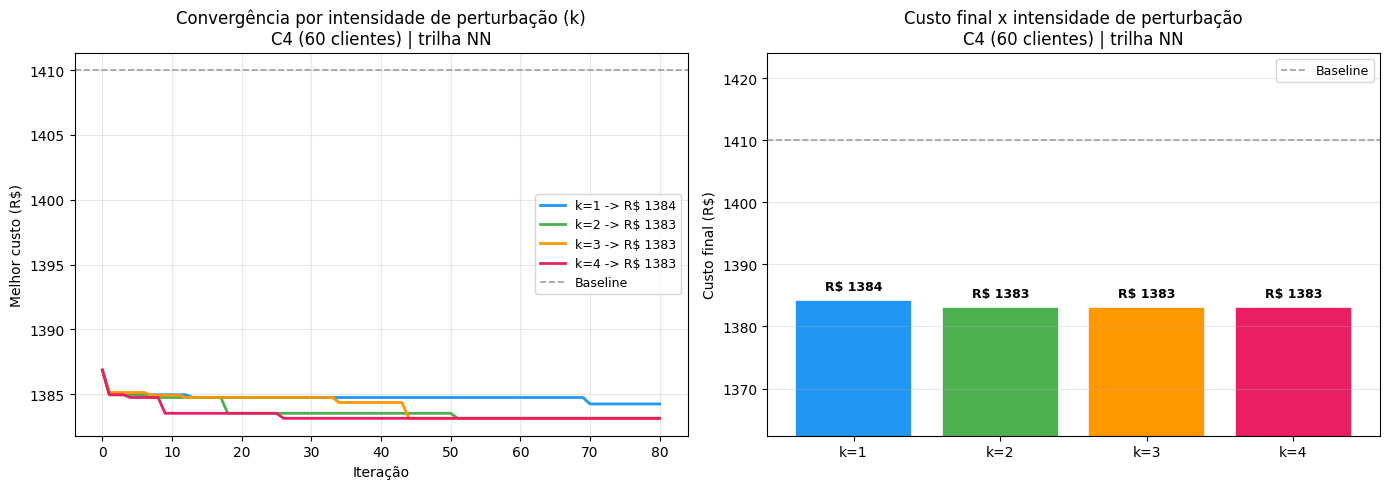

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
lista_cores = [CORES["k1"], CORES["k2"], CORES["k3"], CORES["k4"]]

ax = axes[0]
for idx, k in enumerate(K_VALORES):
    hist = resultados_k[k]["history"]
    ax.plot([h["iteration"] for h in hist], [h["best_cost"] for h in hist],
            color=lista_cores[idx], linewidth=2, label=f"k={k} -> R$ {resultados_k[k]['custo']:.0f}")
ax.axhline(custo_baseline, color=CORES["baseline"], linestyle="--", linewidth=1.2, label="Baseline")
ax.set_xlabel("Iteração")
ax.set_ylabel("Melhor custo (R$)")
ax.set_title(f"Convergência por intensidade de perturbação (k)\n{INSTANCIA_TRABALHO}")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
custos = [resultados_k[k]["custo"] for k in K_VALORES]
bars = ax2.bar([f"k={k}" for k in K_VALORES], custos, color=lista_cores, edgecolor="white", linewidth=1.2)
for bar, v in zip(bars, custos):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(custos) * 0.0008,
             f"R$ {v:.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax2.axhline(custo_baseline, color=CORES["baseline"], linestyle="--", linewidth=1.2, label="Baseline")
ax2.set_ylabel("Custo final (R$)")
ax2.set_title(f"Custo final x intensidade de perturbação\n{INSTANCIA_TRABALHO}")
ax2.set_ylim(min(custos) * 0.985, max(max(custos), custo_baseline) * 1.01)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "sensibilidade_k.png", dpi=150, bbox_inches="tight")
plt.show()

As curvas de convergência têm formatos coerentes com a teoria da intensidade, ainda que o custo final seja quase o mesmo. Todas despencam de R$ 1.410,00 para cerca de R$ 1.385,00 nas primeiras dez iterações — quase todo o ganho ocorre nesse trecho inicial. A diferença entre os `k` está na velocidade: `k=4` atinge o piso de R$ 1.383,14 por volta da iteração 10, enquanto `k=1` estaciona um degrau acima (R$ 1.384,25) e não consegue mais escapar até o fim. Perturbações mais intensas, portanto, alcançam o melhor ótimo local mais cedo, mas o teto de qualidade é compartilhado por todos os `k ≥ 2`. O painel de barras confirma a leitura: as quatro configurações ficam visivelmente abaixo do baseline e praticamente empatadas entre si.

### 1.2 Efeito do número de iterações `N`

Fixamos `k` no melhor valor da subseção anterior e variamos `N` em {20, 50, 100, 150, 200}. Como a semente é fixa, uma execução mais longa contém integralmente a trajetória de uma mais curta, o que torna o melhor custo monotonicamente não crescente em `N` e permite ler o ganho marginal de cada bloco adicional de iterações.

In [11]:
N_VALORES = [20, 50, 100, 150, 200]
K_ESCOLHIDO = melhor_k

resultados_N = {}
custo_anterior = custo_baseline

print(f"Experimento 2 — efeito de N | k={K_ESCOLHIDO} | perturbação={PERTURBACAO} | {INSTANCIA_TRABALHO}")
print(f"{'N':>4} | {'Custo final':>12} | {'Ganho vs BL':>12} | {'Tempo (s)':>10} | {'Ganho marginal':>15}")
print("-" * 70)

for N in N_VALORES:
    t0 = time.time()
    sol, hist = iterated_local_search(
        initial_solution=baseline_solution, D=D, q=q, s=s, params=params,
        perturbation_type=PERTURBACAO, perturbation_k=K_ESCOLHIDO,
        accept_criterion=ACCEPT, tolerance_pct=TOL,
        n_iterations=N, seed=SEED_FIXO, verbose=False,
    )
    elapsed = time.time() - t0
    custo = total_solution_cost(sol, D, params)
    ganho = (custo_baseline - custo) / custo_baseline * 100
    marginal = custo_anterior - custo
    resultados_N[N] = {"solution": sol, "history": hist, "custo": custo,
                       "ganho": ganho, "marginal": marginal, "tempo": elapsed}
    print(f"{N:>4} | R$ {custo:>9.2f} | {ganho:>10.2f}% | {elapsed:>9.2f} | R$ {marginal:>10.2f}")
    custo_anterior = custo

print("\nGanho marginal como % do custo baseline:")
for N in N_VALORES:
    mp = abs(resultados_N[N]["marginal"]) / custo_baseline * 100
    flag = "  <- retorno decrescente" if mp < 0.5 else ""
    print(f"  N={N:>3}: {mp:.3f}%{flag}")

Experimento 2 — efeito de N | k=2 | perturbação=double_bridge | C4 (60 clientes) | trilha NN
   N |  Custo final |  Ganho vs BL |  Tempo (s) |  Ganho marginal
----------------------------------------------------------------------


  20 | R$   1383.53 |       1.88% |      6.84 | R$      26.47


  50 | R$   1383.53 |       1.88% |     15.03 | R$       0.00


 100 | R$   1383.14 |       1.90% |     28.00 | R$       0.39


 150 | R$   1383.14 |       1.90% |     41.85 | R$       0.00


 200 | R$   1383.14 |       1.90% |     55.39 | R$       0.00

Ganho marginal como % do custo baseline:
  N= 20: 1.877%
  N= 50: 0.000%  <- retorno decrescente
  N=100: 0.027%  <- retorno decrescente
  N=150: 0.000%  <- retorno decrescente
  N=200: 0.000%  <- retorno decrescente


O retorno decrescente é acentuado e bem definido. Em apenas 20 iterações o ILS já alcança R$ 1.383,53 — uma redução de R$ 26,47 sobre o baseline, ou 1,88% dos 1,90% totais. O bloco de 20 a 50 iterações não acrescenta nada (ganho marginal de R$ 0,00). Entre 50 e 100 iterações surge uma única melhoria adicional de R$ 0,39 (0,027% do baseline), levando ao custo final de R$ 1.383,14. De 100 a 200 iterações, ganho marginal nulo.

A leitura operacional é direta: o ganho marginal cai abaixo de 0,5% do custo já a partir de N = 50, e não há nenhuma melhoria após N = 100. Em termos de tempo, N = 20 custa 6,8 s, N = 100 custa 28,0 s e N = 200 custa 55,4 s. Para a instância de trabalho, gastar mais de 100 iterações é desperdício de cálculo: dobrar o orçamento de 100 para 200 iterações não altera o resultado e apenas duplica o tempo.

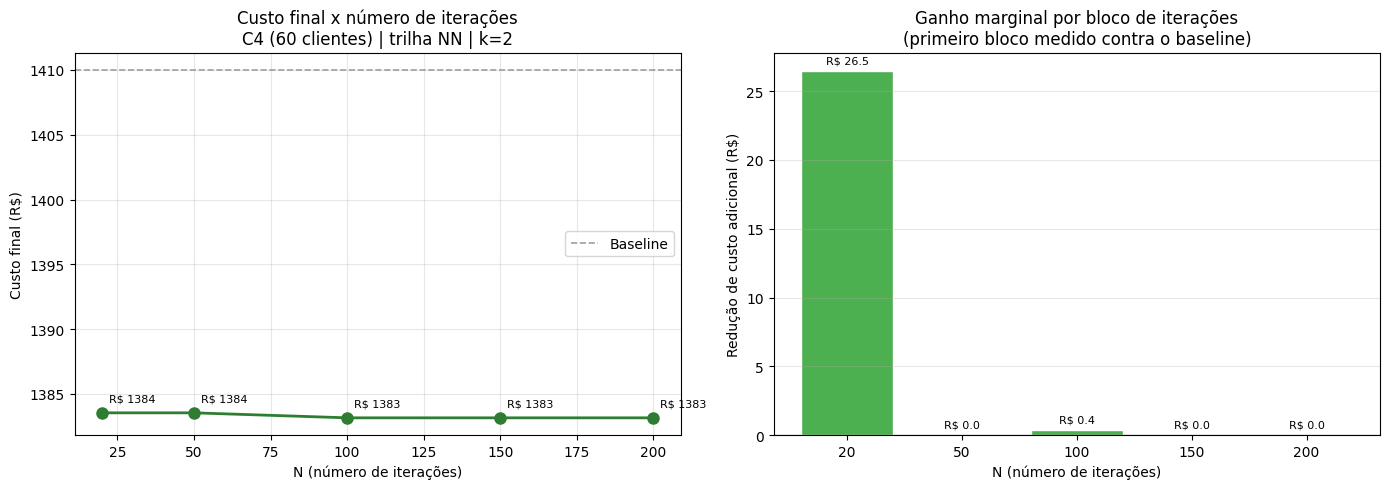

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ns = list(N_VALORES)
custos_N = [resultados_N[n]["custo"] for n in ns]

ax = axes[0]
ax.plot(ns, custos_N, "o-", color=CORES["ils"], linewidth=2, markersize=8)
ax.axhline(custo_baseline, color=CORES["baseline"], linestyle="--", linewidth=1.2, label="Baseline")
ax.set_xlabel("N (número de iterações)")
ax.set_ylabel("Custo final (R$)")
ax.set_title(f"Custo final x número de iterações\n{INSTANCIA_TRABALHO} | k={K_ESCOLHIDO}")
ax.legend()
ax.grid(True, alpha=0.3)
for x, y in zip(ns, custos_N):
    ax.annotate(f"R$ {y:.0f}", (x, y), textcoords="offset points", xytext=(5, 8), fontsize=8)

ax2 = axes[1]
marginais = [resultados_N[n]["marginal"] for n in ns]
ax2.bar([str(n) for n in ns], marginais, color=CORES["k2"], edgecolor="white")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_xlabel("N (número de iterações)")
ax2.set_ylabel("Redução de custo adicional (R$)")
ax2.set_title("Ganho marginal por bloco de iterações\n(primeiro bloco medido contra o baseline)")
ax2.grid(True, alpha=0.3, axis="y")
for i, v in enumerate(marginais):
    ax2.text(i, v + max(marginais) * 0.02, f"R$ {v:.1f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig(IMAGES_DIR / "sensibilidade_N.png", dpi=150, bbox_inches="tight")
plt.show()

O painel da esquerda mostra a curva de custo praticamente horizontal a partir de N = 20, sempre colada ao piso e distante do baseline tracejado. O painel da direita traduz isso em ganho marginal: uma barra única e dominante de R$ 26,5 no primeiro bloco, seguida de barras nulas ou desprezíveis. Visualmente, fica evidente que o orçamento de iterações relevante para esta instância é pequeno — a curva de aprendizado se esgota antes de N = 100.

Em síntese da Seção 1: o melhor `k` é 2, com sensibilidade fraca (qualquer `k ≥ 2` empata), e o `N` recomendado fica entre 50 e 100, pois além disso o ganho é nulo. Esses valores alimentam o diagnóstico de convergência e a recomendação operacional das próximas seções.

## Seção 2 — Diagnóstico de convergência

A curva de convergência conta onde o algoritmo melhorou, onde ficou preso e o que isso diz sobre a solução final. Falta a ela, porém, distinguir dois motivos para o ILS parar de melhorar. Na convergência genuína o algoritmo explorou bem o espaço e encontrou um bom ótimo local — mais iterações pouco ajudariam. Na estagnação prematura ele ficou preso num ótimo ruim porque a perturbação não foi forte o bastante para escapar — aí mais iterações, com perturbação mais agressiva, poderiam ajudar.

A distinção se faz observando quando ocorreu a última melhoria e o que acontece com o custo corrente depois dela. Se a última melhoria foi na iteração 12 de 150, o algoritmo passou 138 iterações sem progredir — estagnação. Se foi na iteração 145, ainda estava aprendendo quando o orçamento acabou. Rodamos o diagnóstico com a configuração da Equipe 2 (double-bridge + estrito), usando o `k` ótimo da Seção 1 e N = 150 iterações.

In [13]:
CONFIG_EQUIPE = dict(
    perturbation_type=PERTURBACAO, perturbation_k=K_ESCOLHIDO,
    accept_criterion=ACCEPT, tolerance_pct=TOL,
)
N_DIAG = 150

sol_diag, hist_diag = iterated_local_search(
    initial_solution=baseline_solution, D=D, q=q, s=s, params=params,
    n_iterations=N_DIAG, seed=SEED_FIXO, verbose=False, **CONFIG_EQUIPE,
)

df_hist = pd.DataFrame(hist_diag)
df_hist["nova_melhor"] = df_hist["best_cost"] < df_hist["best_cost"].shift(1, fill_value=float("inf"))
melhorias = df_hist[df_hist["nova_melhor"]]

custo_inicial = df_hist.iloc[0]["current_cost"]      # custo já refinado pela busca local na iteração 0
custo_final = df_hist.iloc[-1]["best_cost"]
n_melhorias = max(len(melhorias) - 1, 0)
ultima_melhora = int(melhorias.iloc[-1]["iteration"]) if len(melhorias) > 1 else 0
ganho_total = (custo_inicial - custo_final) / custo_inicial * 100
pct_ociosa = (N_DIAG - ultima_melhora) / N_DIAG * 100
ganho_vs_baseline = (custo_baseline - custo_final) / custo_baseline * 100

print(f"Configuração Equipe 2 | {INSTANCIA_TRABALHO} | k={K_ESCOLHIDO} | N={N_DIAG}")
print("-" * 60)
print(f"Custo baseline (busca local Aula 8) : R$ {custo_baseline:.2f}")
print(f"Custo na iteração 0 (após 2-opt+Reloc): R$ {custo_inicial:.2f}")
print(f"Custo final ILS                      : R$ {custo_final:.2f}")
print(f"Ganho metaheurístico (iter 0 -> fim) : {ganho_total:.2f}%")
print(f"Ganho total vs baseline              : {ganho_vs_baseline:.2f}%")
print(f"Número de melhorias                  : {n_melhorias}")
print(f"Última melhoria                      : iteração {ultima_melhora} / {N_DIAG}")
print(f"Iterações sem melhoria               : {N_DIAG - ultima_melhora} ({pct_ociosa:.0f}% do total)")

if pct_ociosa > 50:
    diagnostico = "ESTAGNAÇÃO — o algoritmo parou de melhorar cedo."
elif pct_ociosa > 25:
    diagnostico = "CONVERGÊNCIA PARCIAL — há alguma estagnação."
else:
    diagnostico = "CONVERGÊNCIA ATIVA — ainda melhorava perto do fim."
print(f"\nDiagnóstico automático: {diagnostico}")

Configuração Equipe 2 | C4 (60 clientes) | trilha NN | k=2 | N=150
------------------------------------------------------------
Custo baseline (busca local Aula 8) : R$ 1410.00
Custo na iteração 0 (após 2-opt+Reloc): R$ 1386.86
Custo final ILS                      : R$ 1383.14
Ganho metaheurístico (iter 0 -> fim) : 0.27%
Ganho total vs baseline              : 1.90%
Número de melhorias                  : 4
Última melhoria                      : iteração 51 / 150
Iterações sem melhoria               : 99 (66% do total)

Diagnóstico automático: ESTAGNAÇÃO — o algoritmo parou de melhorar cedo.


O diagnóstico confirma a decomposição antecipada na Seção 1. Dos 1,90% de ganho total sobre o baseline, a maior parte vem da busca local reaplicada na iteração 0: o 2-opt + Relocate sobre a solução da Aula 8 derruba o custo de R$ 1.410,00 para R$ 1.386,86 (R$ 23,14, ou 1,64%). O ganho propriamente metaheurístico — o que as perturbações double-bridge acrescentam da iteração 0 ao fim — é de apenas R$ 3,72, 0,27%. Foram quatro melhorias ao longo das 150 iterações, a última na iteração 51, deixando 99 iterações (66%) sem progresso.

A regra automática classifica isso como estagnação por ultrapassar 50% de iterações ociosas, mas o cruzamento com a Seção 1 corrige a leitura. Não se trata de uma armadilha que mais iterações ou perturbações mais fortes resolveriam: a análise de `N` mostrou ganho nulo de N = 100 a N = 200, e a análise de `k` mostrou que intensificar a perturbação (k = 4) não melhora o resultado. O algoritmo, portanto, atingiu convergência genuína para esta vizinhança por volta da iteração 51 — esgotou o que double-bridge + 2-opt + Relocate conseguem extrair de C4-NN, e não há sinal de que esteja preso num ótimo ruim escapável. A fração ociosa elevada é consequência do orçamento de 150 iterações ser muito maior do que o necessário, não de uma falha de exploração.

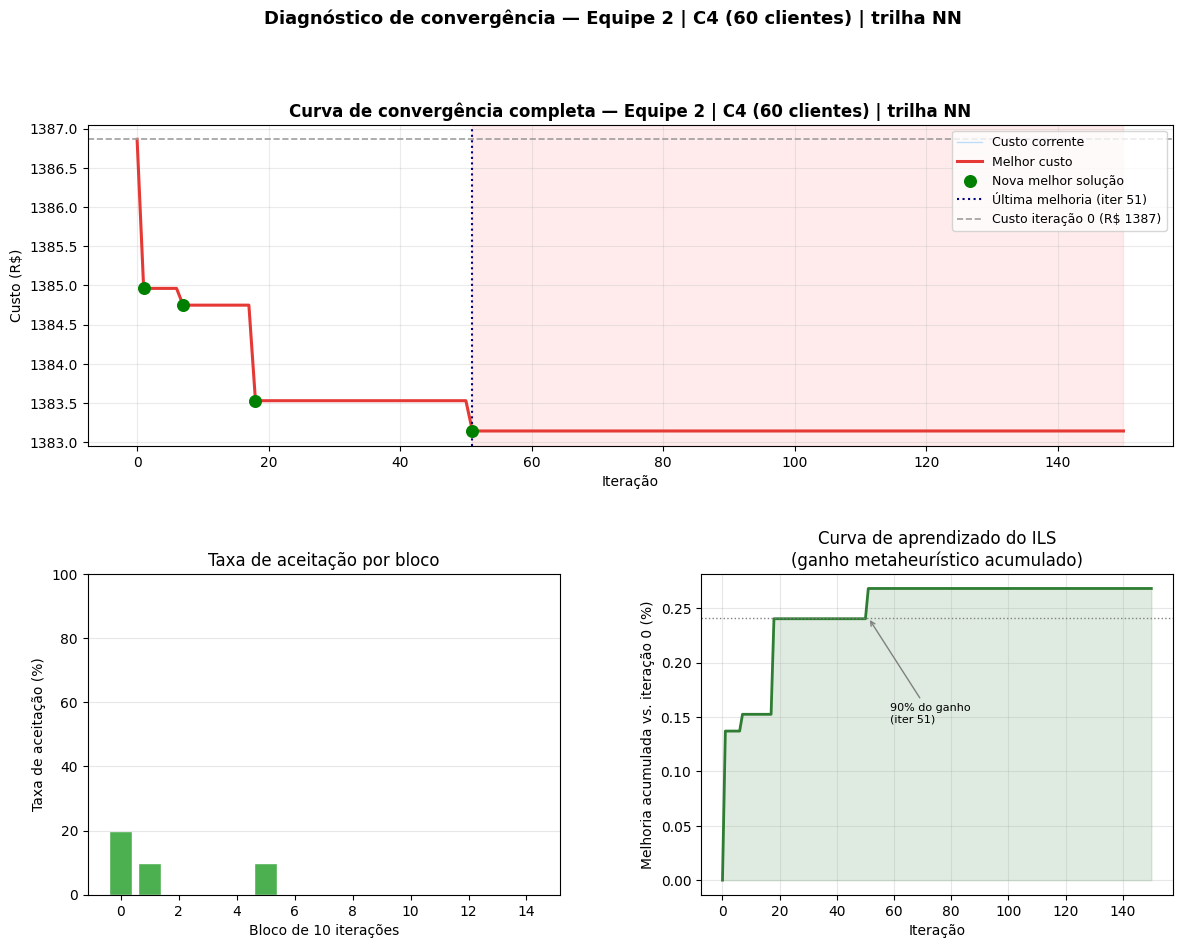

90% do ganho metaheurístico atingido na iteração 51 de 150.


In [14]:
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

iters = df_hist["iteration"].values
currnt = df_hist["current_cost"].values
best = df_hist["best_cost"].values

# Painel 1 — curva de convergência completa
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(iters, currnt, color=CORES["atual"], alpha=0.6, linewidth=1.0, label="Custo corrente")
ax1.plot(iters, best, color=CORES["melhor"], linewidth=2.2, label="Melhor custo")
if len(melhorias) > 1:
    ax1.scatter(melhorias["iteration"].iloc[1:], melhorias["best_cost"].iloc[1:],
                color="green", s=70, zorder=5, label="Nova melhor solução")
ax1.axvline(ultima_melhora, color="navy", linestyle=":", linewidth=1.5,
            label=f"Última melhoria (iter {ultima_melhora})")
ax1.axhline(custo_inicial, color=CORES["baseline"], linestyle="--", linewidth=1.2,
            label=f"Custo iteração 0 (R$ {custo_inicial:.0f})")
ax1.axvspan(ultima_melhora, N_DIAG, alpha=0.08, color="red")
ax1.set_xlabel("Iteração")
ax1.set_ylabel("Custo (R$)")
ax1.set_title(f"Curva de convergência completa — Equipe 2 | {INSTANCIA_TRABALHO}", fontweight="bold")
ax1.legend(fontsize=9, loc="upper right")
ax1.grid(True, alpha=0.25)

# Painel 2 — taxa de aceitação por bloco de 10 iterações
ax2 = fig.add_subplot(gs[1, 0])
bloco = 10
df_ls = df_hist[df_hist["iteration"] > 0].copy()
df_ls["bloco"] = (df_ls["iteration"] - 1) // bloco
taxa = df_ls.groupby("bloco")["accepted"].mean() * 100
ax2.bar(taxa.index, taxa.values, color=CORES["k2"], edgecolor="white")
ax2.set_xlabel(f"Bloco de {bloco} iterações")
ax2.set_ylabel("Taxa de aceitação (%)")
ax2.set_title("Taxa de aceitação por bloco")
ax2.set_ylim(0, 100)
ax2.grid(True, alpha=0.3, axis="y")

# Painel 3 — ganho acumulado vs. custo da iteração 0
ax3 = fig.add_subplot(gs[1, 1])
melhoria_acum = (custo_inicial - best) / custo_inicial * 100
ax3.plot(iters, melhoria_acum, color=CORES["ils"], linewidth=2)
ax3.fill_between(iters, 0, melhoria_acum, alpha=0.15, color=CORES["ils"])
ax3.set_xlabel("Iteração")
ax3.set_ylabel("Melhoria acumulada vs. iteração 0 (%)")
ax3.set_title("Curva de aprendizado do ILS\n(ganho metaheurístico acumulado)")
ax3.grid(True, alpha=0.3)
if melhoria_acum.max() > 0:
    ganho_90 = melhoria_acum.max() * 0.90
    iter_90 = int(iters[np.argmax(melhoria_acum >= ganho_90)])
    ax3.axhline(ganho_90, color="gray", linestyle=":", linewidth=1)
    ax3.annotate(f"90% do ganho\n(iter {iter_90})", (iter_90, ganho_90),
                 xytext=(iter_90 + max(N_DIAG * 0.05, 1), ganho_90 * 0.6),
                 fontsize=8, arrowprops=dict(arrowstyle="->", color="gray"))
else:
    iter_90 = 0

plt.suptitle(f"Diagnóstico de convergência — Equipe 2 | {INSTANCIA_TRABALHO}",
             fontsize=13, fontweight="bold", y=0.995)
plt.savefig(IMAGES_DIR / "diagnostico_convergencia.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"90% do ganho metaheurístico atingido na iteração {iter_90} de {N_DIAG}.")

O painel superior mostra um descida em quatro degraus: o melhor custo cai de R$ 1.386,86 para R$ 1.385,0 (iteração 1), R$ 1.384,75 (iteração 7), R$ 1.383,53 (iteração 18) e R$ 1.383,14 (iteração 51), estabilizando daí em diante. A faixa vermelha cobre as 99 iterações ociosas após a última melhoria. A linha de custo corrente praticamente coincide com a de melhor custo porque o critério estrito só aceita reduções — sob aceitação estrita, a solução corrente nunca piora, então as duas curvas se sobrepõem.

O painel inferior esquerdo confirma o padrão: aceitações ocorrem apenas nos blocos iniciais (cerca de 20% no bloco 0, 10% nos blocos 1 e 5) e zeram completamente depois do bloco 5. A taxa de aceitação cai a zero não por exploração de regiões de custo parecido, mas porque o critério estrito rejeita tudo que não melhora, e melhorias deixam de aparecer após a iteração 51. O painel inferior direito fecha a leitura: a curva de aprendizado metaheurístico sobe em degraus até o teto de 0,27% e satura exatamente na iteração 51, onde os 90% do ganho são atingidos. Confirma-se que, para esta instância, um orçamento de 50 a 60 iterações basta — tudo além disso é tempo de cálculo sem retorno.

### 2.2 Critério de aceitação: estrito × tolerância

A Equipe 2 adota o critério estrito, mas vale medir o que se perde ou se ganha ao permitir pioras controladas. O critério de tolerância aceita soluções até 3% piores que a corrente, na esperança de que oscilar para regiões piores ajude a escapar de ótimos locais. Comparamos as duas configurações com a mesma perturbação, o mesmo `k` e N = 150.

In [15]:
resultados_aceit = {}

for criterio, delta in [("strict", 0.0), ("tolerance", 0.03)]:
    _, hist = iterated_local_search(
        initial_solution=baseline_solution, D=D, q=q, s=s, params=params,
        perturbation_type=PERTURBACAO, perturbation_k=K_ESCOLHIDO,
        accept_criterion=criterio, tolerance_pct=delta,
        n_iterations=N_DIAG, seed=SEED_FIXO, verbose=False,
    )
    resultados_aceit[criterio] = pd.DataFrame(hist)

print(f"Critério     | Custo final | Ganho vs iter 0 | Taxa de aceitação")
print("-" * 62)
for criterio in ["strict", "tolerance"]:
    dfp = resultados_aceit[criterio]
    cf = dfp.iloc[-1]["best_cost"]
    g = (custo_inicial - cf) / custo_inicial * 100
    ta = dfp[dfp["iteration"] > 0]["accepted"].mean() * 100
    print(f"{criterio:<12} | R$ {cf:>8.2f} | {g:>13.2f}% | {ta:>15.1f}%")

Critério     | Custo final | Ganho vs iter 0 | Taxa de aceitação
--------------------------------------------------------------
strict       | R$  1383.14 |          0.27% |             2.7%
tolerance    | R$  1383.53 |          0.24% |           100.0%


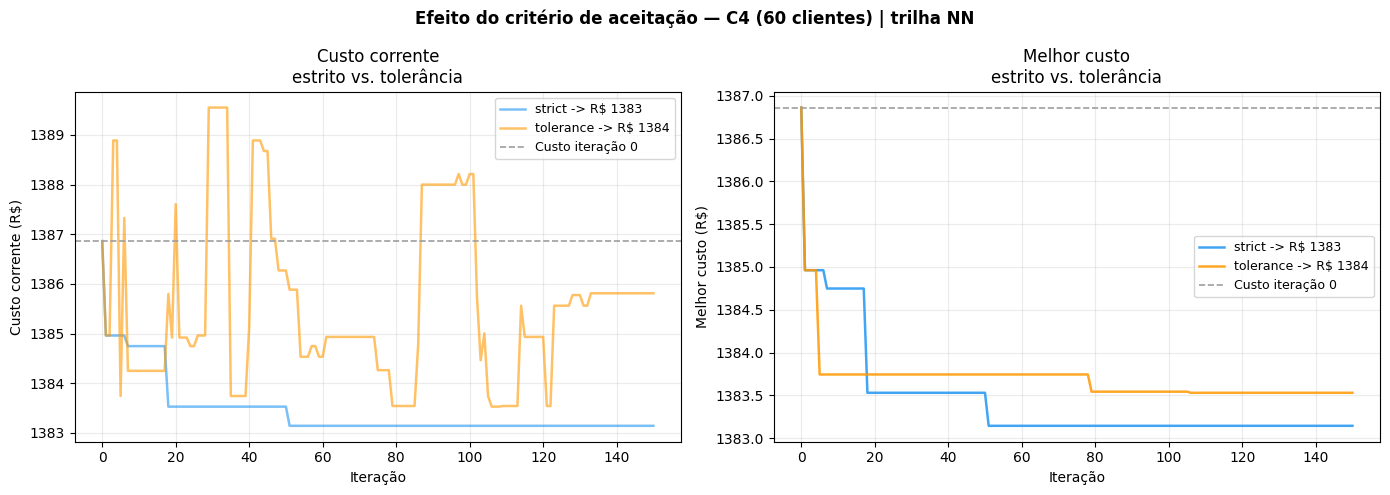

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, label in [(axes[0], "current_cost", "Custo corrente"),
                       (axes[1], "best_cost", "Melhor custo")]:
    for criterio, cor in [("strict", CORES["k1"]), ("tolerance", CORES["k3"])]:
        dfp = resultados_aceit[criterio]
        cf = dfp.iloc[-1]["best_cost"]
        ax.plot(dfp["iteration"], dfp[col], color=cor, linewidth=1.8,
                alpha=0.85 if col == "best_cost" else 0.6,
                label=f"{criterio} -> R$ {cf:.0f}")
    ax.axhline(custo_inicial, color=CORES["baseline"], linestyle="--", linewidth=1.2,
               label="Custo iteração 0")
    ax.set_xlabel("Iteração")
    ax.set_ylabel(f"{label} (R$)")
    ax.set_title(f"{label}\nestrito vs. tolerância")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)

plt.suptitle(f"Efeito do critério de aceitação — {INSTANCIA_TRABALHO}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "comparacao_criterios.png", dpi=150, bbox_inches="tight")
plt.show()

A comparação favorece o critério estrito da Equipe 2. O painel da esquerda mostra a diferença de regime: o estrito (azul) desce em degraus e fica imóvel no piso de R$ 1.383,14, enquanto a tolerância (laranja) oscila entre R$ 1.383,5 e R$ 1.389,5, subindo várias vezes acima do custo da iteração 0. Essa oscilação é o random walk esperado de um critério que aceita 100% dos candidatos — como a busca local repara cada perturbação, nenhum candidato fica mais de 3% pior que a solução corrente, e tudo é aceito.

O ponto decisivo está no painel da direita: a oscilação da tolerância não se converteu em melhor solução. O melhor custo do estrito termina em R$ 1.383,14, abaixo dos R$ 1.383,53 da tolerância. A exploração mais agressiva foi ruído sem benefício nesta instância — coerente com o diagnóstico de que C4-NN já converge genuinamente, sem ótimos locais ruins dos quais a tolerância precisaria escapar. Para o perfil de instâncias da Prolog, o critério estrito entrega resultado igual ou melhor com trajetória estável e previsível, o que sustenta a escolha da equipe.

## Seção 3 — Escalabilidade: o ILS funciona igual em instâncias maiores?

A demanda diária da Prolog varia, e o algoritmo precisa funcionar bem em diferentes escalas. A escalabilidade responde a duas perguntas práticas: o ganho do ILS cresce ou encolhe com o número de clientes, e o tempo de cálculo cresce de forma aceitável. A teoria sugere que em instâncias pequenas a busca local já encontra bons ótimos por conta própria, sobrando pouco para a metaheurística; em instâncias maiores, com espaço de soluções muito maior e ótimos locais mais distantes, a perturbação ganharia valor.

Rodamos o ILS da Equipe 2 sobre as quatro instâncias C1–C4 na trilha NN, com `k` = 2 e N = 80. Como a Seção 2 mostrou que o ganho contra o baseline carregado mistura o refinamento da busca local na iteração 0 com o ganho metaheurístico, registramos as duas parcelas em separado: o ganho total sobre a solução da Aula 8 e o ganho metaheurístico puro a partir do custo já refinado na iteração 0.

### 3.1 Execução do ILS nas quatro instâncias

In [17]:
N_ESCALA = 80
HEUR_ESCALA = "NN"

resultados_escala = []

for nome_inst in INSTANCIAS:
    inst = INST[nome_inst]
    D_i, q_i, s_i, params_i = inst["D"], inst["q"], inst["s"], inst["params"]
    sol_bl_i = INITIAL_SOLUTIONS[HEUR_ESCALA][nome_inst]
    n_cli = inst["n_clientes"]

    c_bl = total_solution_cost(sol_bl_i, D_i, params_i)

    t0 = time.time()
    sol_ils_i, hist_i = iterated_local_search(
        initial_solution=sol_bl_i, D=D_i, q=q_i, s=s_i, params=params_i,
        n_iterations=N_ESCALA, seed=SEED_FIXO, verbose=False, **CONFIG_EQUIPE,
    )
    t_ils = time.time() - t0

    c_iter0 = hist_i[0]["current_cost"]
    c_ils = total_solution_cost(sol_ils_i, D_i, params_i)
    ganho_total = (c_bl - c_ils) / c_bl * 100
    ganho_meta = (c_iter0 - c_ils) / c_iter0 * 100

    resultados_escala.append({
        "instancia": nome_inst, "n_clientes": n_cli,
        "custo_bl": c_bl, "custo_iter0": c_iter0, "custo_ils": c_ils,
        "ganho_total_pct": ganho_total, "ganho_meta_pct": ganho_meta,
        "t_ils": t_ils,
        "feasible_ils": is_solution_feasible(sol_ils_i, D_i, q_i, s_i, params_i),
        "history": hist_i, "solution_ils": sol_ils_i,
    })

df_escala = pd.DataFrame([{k: v for k, v in r.items() if k not in ("history", "solution_ils")}
                          for r in resultados_escala])
display(df_escala.set_index("instancia").round(
    {"custo_bl": 2, "custo_iter0": 2, "custo_ils": 2,
     "ganho_total_pct": 2, "ganho_meta_pct": 3, "t_ils": 2}))

,n_clientes,custo_bl,custo_iter0,custo_ils,ganho_total_pct,ganho_meta_pct,t_ils,feasible_ils
instancia,,,,,,,,
C1,10,422.38,422.38,422.38,0.00,0.000,0.15,True
C2,25,712.49,710.47,710.47,0.28,0.000,2.12,True
C3,40,1043.69,779.76,775.01,25.74,0.609,3.67,True
C4,60,1410.00,1386.86,1383.14,1.90,0.268,22.93,True


A tabela separa com nitidez os dois efeitos e desfaz uma interpretação ingênua. O ganho total sobre o baseline é errático: 0,00% em C1, 0,28% em C2, 25,74% em C3 e 1,90% em C4. O salto de C3 não vem da metaheurística — vem do fato de que a solução NN-C3 salva na Aula 8 estava mal refinada (R$ 1.043,69), e o 2-opt + Relocate reaplicado na iteração 0 a derruba para R$ 779,76. É o mesmo achado de não idempotência documentado na Aula 11, agora quantificado: o Swap aplicado por último na Aula 8 deixou a rota NN-C3 numa configuração que o 2-opt + Relocate melhora em 25%.

O ganho metaheurístico puro, medido a partir do custo já refinado da iteração 0, é pequeno em todas as instâncias: 0,00% (C1), 0,00% (C2), 0,609% (C3) e 0,268% (C4). Ele não cresce monotonicamente com o número de clientes — o pico está em C3 (40 clientes), não em C4 (60). A hipótese de que o ILS se torna mais valioso em instâncias maiores não se confirma para esta base: a busca local já resolve a maior parte do problema, e o que sobra para as perturbações é marginal. O tempo, por outro lado, cresce de forma acentuada — de 0,15 s em C1 para 22,93 s em C4. O salto de C3 (3,67 s) para C4 (22,93 s) é de cerca de seis vezes para 1,5 vez mais clientes, sinal do custo super-linear do Relocate, que reavalia a solução inteira a cada movimento candidato. Todas as soluções permanecem viáveis.

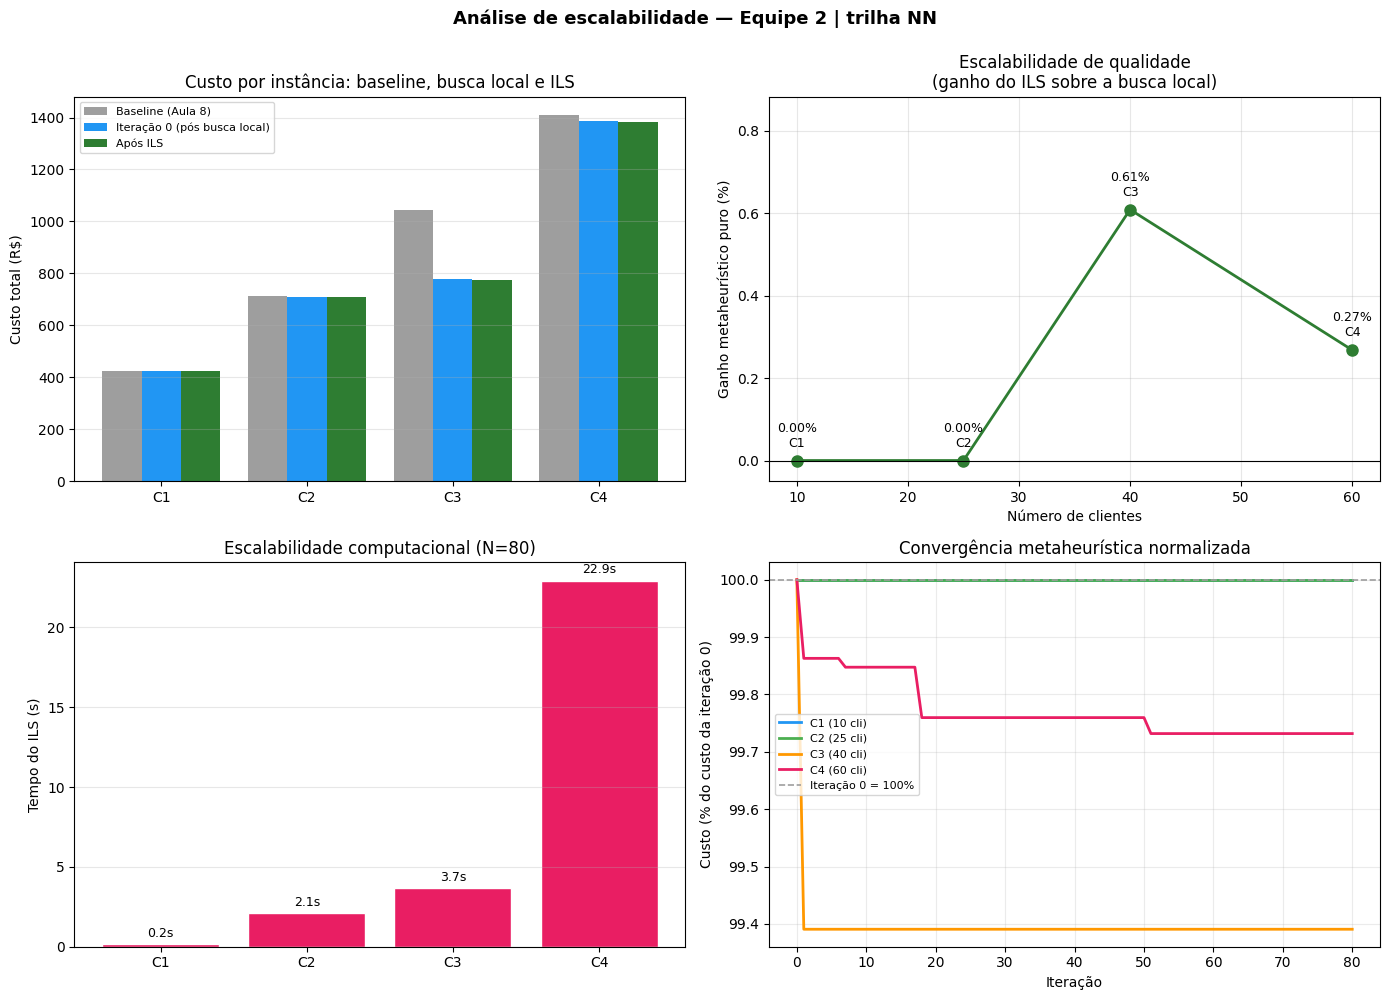

In [18]:
resultados_escala = sorted(resultados_escala, key=lambda r: r["n_clientes"])
xs = [r["instancia"] for r in resultados_escala]
ns = np.array([r["n_clientes"] for r in resultados_escala])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Painel 1 — custos: baseline, iteração 0 (pós busca local) e ILS
ax = axes[0, 0]
x = np.arange(len(xs))
w = 0.27
ax.bar(x - w, [r["custo_bl"] for r in resultados_escala], w, label="Baseline (Aula 8)", color=CORES["baseline"])
ax.bar(x, [r["custo_iter0"] for r in resultados_escala], w, label="Iteração 0 (pós busca local)", color=CORES["k1"])
ax.bar(x + w, [r["custo_ils"] for r in resultados_escala], w, label="Após ILS", color=CORES["ils"])
ax.set_xticks(x)
ax.set_xticklabels(xs)
ax.set_ylabel("Custo total (R$)")
ax.set_title("Custo por instância: baseline, busca local e ILS")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis="y")

# Painel 2 — ganho metaheurístico vs número de clientes
ax = axes[0, 1]
gm = [r["ganho_meta_pct"] for r in resultados_escala]
ax.plot(ns, gm, "o-", color=CORES["ils"], linewidth=2, markersize=8)
for x_p, y_p, inst in zip(ns, gm, xs):
    ax.annotate(f"{y_p:.2f}%\n{inst}", (x_p, y_p), textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=9)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Número de clientes")
ax.set_ylabel("Ganho metaheurístico puro (%)")
ax.set_title("Escalabilidade de qualidade\n(ganho do ILS sobre a busca local)")
ax.set_ylim(-0.05, max(gm) * 1.45)
ax.grid(True, alpha=0.3)

# Painel 3 — tempo computacional
ax = axes[1, 0]
ts = [r["t_ils"] for r in resultados_escala]
ax.bar(xs, ts, color=CORES["k4"], edgecolor="white")
ax.set_ylabel("Tempo do ILS (s)")
ax.set_title(f"Escalabilidade computacional (N={N_ESCALA})")
ax.grid(True, alpha=0.3, axis="y")
for i, v in enumerate(ts):
    ax.text(i, v + max(ts) * 0.02, f"{v:.1f}s", ha="center", fontsize=9)

# Painel 4 — convergência metaheurística normalizada pelo custo da iteração 0
ax = axes[1, 1]
paleta = [CORES["k1"], CORES["k2"], CORES["k3"], CORES["k4"]]
for idx, r in enumerate(resultados_escala):
    dfh = pd.DataFrame(r["history"])
    ax.plot(dfh["iteration"], dfh["best_cost"] / r["custo_iter0"] * 100,
            color=paleta[idx % len(paleta)], linewidth=2,
            label=f"{r['instancia']} ({r['n_clientes']} cli)")
ax.axhline(100, color=CORES["baseline"], linestyle="--", linewidth=1.2, label="Iteração 0 = 100%")
ax.set_xlabel("Iteração")
ax.set_ylabel("Custo (% do custo da iteração 0)")
ax.set_title("Convergência metaheurística normalizada")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)

plt.suptitle("Análise de escalabilidade — Equipe 2 | trilha NN", fontsize=13, fontweight="bold", y=0.995)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "escalabilidade.png", dpi=150, bbox_inches="tight")
plt.show()

Os quatro quadros consolidam a leitura. No painel de custos, C1 e C2 têm as três barras praticamente idênticas — não há o que melhorar além da busca local. C3 exibe o degrau característico entre o baseline cinza e a barra da iteração 0, a marca visual da reaplicação do 2-opt + Relocate; já a contribuição do ILS (azul para verde) é imperceptível na escala da figura em todas as instâncias.

O painel de qualidade mostra que o ganho metaheurístico não escala com o tamanho: ele é nulo até 25 clientes, atinge o pico de 0,61% em C3 (40 clientes) e recua para 0,27% em C4 (60 clientes). A curva tem forma de corcova, não de rampa — refuta, para esta base, a hipótese de que o ILS se torna progressivamente mais valioso em instâncias maiores. O painel de tempo conta a história oposta e mais preocupante: o custo computacional cresce de forma super-linear, de 0,15 s em C1 para 22,9 s em C4, com o salto abrupto entre C3 e C4. O painel de convergência normalizada confirma que mesmo a maior descida metaheurística (C3, até 99,39% do custo da iteração 0) é modesta, e que toda a ação ocorre nas primeiras dezenas de iterações. A conclusão operacional é que, com a configuração atual, a restrição determinante para a Prolog é tempo, não qualidade — e o gargalo está no Relocate aplicado a instâncias grandes.

## Seção 4 — Síntese e recomendação para a operação

A pergunta de abertura era como o ILS se comporta. As três análises convergem para uma resposta consistente. Sobre os parâmetros, a sensibilidade a `k` é fraca — qualquer `k ≥ 2` empata no melhor custo, com `k = 2` à frente por uma margem desprezível — e o `N` tem retorno decrescente abrupto: 20 iterações já capturam 1,88% dos 1,90% de ganho total em C4, e não há melhoria alguma além de 100 iterações. Sobre a convergência, o algoritmo atinge convergência genuína por volta da iteração 51 na instância de trabalho; a fração ociosa elevada reflete um orçamento de iterações maior do que o necessário, não uma armadilha de ótimo local, conforme confirmado pela ausência de ganho ao aumentar `N` ou `k`. O critério estrito da equipe iguala ou supera a tolerância de 3%, que apenas oscila sem benefício.

A descoberta central, porém, é a decomposição do ganho. O que parecia ganho do ILS é, em sua quase totalidade, o refinamento da busca local reaplicada na iteração 0: o ganho metaheurístico puro fica entre 0,00% e 0,61% nas quatro instâncias e não cresce com o tamanho do problema. O ILS não é o motor da economia — a busca local é. O papel da metaheurística é um polimento final modesto e barato em instâncias pequenas, que se torna caro em instâncias grandes pelo custo super-linear do Relocate (22,9 s em C4 contra 3,7 s em C3).

Recomendação para a operação diária da Prolog (questão 9). Manter o pipeline Nearest Neighbor + busca local 2-opt + Relocate + Swap como base, e ativar o ILS com a configuração da Equipe 2 — double-bridge, aceitação estrita, `k = 2` — limitando o orçamento a `N = 50` a `100` iterações. Essa faixa esgota o ganho disponível e mantém o tempo na casa de dezenas de segundos para instâncias de até 60 clientes. Gastar mais iterações é desperdício de cálculo comprovado.

Cenários para configuração distinta (questão 10). Sob urgência de roteamento, `N = 20` entrega 98,6% do ganho em C4 em apenas 6,8 s — vale reduzir o orçamento quando o plano precisa sair em segundos. Para instâncias substancialmente maiores que C4, como a instância de competição, o gargalo deixa de ser o número de iterações e passa a ser o tempo por iteração: aí convém manter `N` baixo e, se necessário, restringir a vizinhança do Relocate, sem trocar o critério de aceitação, já que a tolerância não trouxe ganho nesta base.

### 4.1 Salvamento de artefatos

As tabelas das análises e as soluções finais do ILS são gravadas em `files/` para alimentar o relatório consolidado da Sprint 3; as quatro figuras já foram salvas em `images/` ao longo do notebook. São exportações justificadas por consumo externo (o relatório), não armazenamento de resultados intermediários.

In [19]:
salvos = []

# Tabela de sensibilidade a k (instância de trabalho)
df_k = pd.DataFrame([
    {"k": k, "custo_final": resultados_k[k]["custo"],
     "ganho_total_pct": resultados_k[k]["ganho"], "tempo_s": resultados_k[k]["tempo"]}
    for k in K_VALORES
])
p = OUTPUT_FILES_DIR / "sensibilidade_k_C4.csv"
df_k.to_csv(p, index=False); salvos.append(p)

# Tabela de sensibilidade a N
df_n = pd.DataFrame([
    {"N": N, "custo_final": resultados_N[N]["custo"], "ganho_total_pct": resultados_N[N]["ganho"],
     "ganho_marginal_rs": resultados_N[N]["marginal"], "tempo_s": resultados_N[N]["tempo"]}
    for N in N_VALORES
])
p = OUTPUT_FILES_DIR / "sensibilidade_N_C4.csv"
df_n.to_csv(p, index=False); salvos.append(p)

# Histórico de convergência do diagnóstico (instância de trabalho)
p = OUTPUT_FILES_DIR / "historico_diagnostico_C4.csv"
df_hist.drop(columns=["nova_melhor"]).to_csv(p, index=False); salvos.append(p)

# Tabela de escalabilidade
p = OUTPUT_FILES_DIR / "escalabilidade_C1_C4.csv"
df_escala.to_csv(p, index=False); salvos.append(p)

# Soluções finais do ILS por instância (trilha NN, k=2)
for r in resultados_escala:
    inst = r["instancia"]
    D_i, q_i, s_i, params_i = INST[inst]["D"], INST[inst]["q"], INST[inst]["s"], INST[inst]["params"]
    payload = {
        "equipe": "Equipe 2 (Grupo 2)",
        "heuristic_initial": HEUR_ESCALA,
        "instance": inst,
        "perturbation_type": PERTURBACAO,
        "accept_criterion": ACCEPT,
        "perturbation_k": K_ESCOLHIDO,
        "n_iterations": N_ESCALA,
        "seed": SEED_FIXO,
        "solution": r["solution_ils"],
        "metrics": solution_metrics(r["solution_ils"], D_i, q_i, s_i, params_i),
        "custo_baseline": r["custo_bl"],
        "custo_ils": r["custo_ils"],
        "elapsed_sec": r["t_ils"],
    }
    p = OUTPUT_FILES_DIR / f"solution_ils_sens_nn_{inst}.json"
    p.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")
    salvos.append(p)

print("Arquivos salvos em files/:")
for p in salvos:
    print(" -", p.name)
print(f"\nImagens em images/: {[f.name for f in sorted(IMAGES_DIR.glob('*.png'))]}")

Arquivos salvos em files/:
 - sensibilidade_k_C4.csv
 - sensibilidade_N_C4.csv
 - historico_diagnostico_C4.csv
 - escalabilidade_C1_C4.csv
 - solution_ils_sens_nn_C1.json
 - solution_ils_sens_nn_C2.json
 - solution_ils_sens_nn_C3.json
 - solution_ils_sens_nn_C4.json

Imagens em images/: ['comparacao_criterios.png', 'diagnostico_convergencia.png', 'escalabilidade.png', 'notebook_23_0.png', 'notebook_28_0.png', 'notebook_33_0.png', 'notebook_37_0.png', 'notebook_42_0.png', 'sensibilidade_k.png', 'sensibilidade_N.png']
